# EDIS 8100 · Week 3 · Ethics and Bias Audit

## Auditing a non-completion model before anyone acts on it

**Estimated time: 30 minutes (in-class launch)**

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

## 🎯 What you will be able to do

By the end of this notebook you will be able to:

1. **Load** a real, published, openly licensed learning dataset from the internet, and state where it came from and who collected it before you analyze a single row.
2. **Name** what a model actually predicts, and say why "an at-risk model" is a description of a person while "a model predicting non-completion" is a description of an outcome.
3. **Train** that model on activity data, and read its accuracy honestly against a do-nothing baseline.
4. **Disaggregate** the model's errors by socioeconomic decile and by disability status, and say which of those differences you can actually distinguish from noise once you have made ten comparisons.
5. **Redesign** the feature set, re-run the same audit, and be precise about what the redesign fixed and what it did not.
6. **Compare** what an audit can prove on real data against what it can prove on data whose mechanism was written down in advance.

## How this notebook works

This is a running notebook, not a coding test. Here is everything you need to know:

- **Run the cells in order, top to bottom.** Press `Shift+Enter`, or click the play button to the left of a cell.
- **Nothing here can break your computer,** and nothing here touches your files. The worst thing that can happen is an error message, and an error message is information.
- **If something stops making sense, start over from the top.** In Colab that is `Runtime > Restart and run all`. In Jupyter it is `Kernel > Restart & Run All`. This fixes most problems.
- **You are not expected to read every line of code.** You are expected to read every chart and argue about it.
- The three ✏️ **Your turn** cells already contain working answers, so the notebook runs start to finish before you type anything.

**One change from weeks 1 and 2.** Those notebooks built their own pretend data. This one downloads a real dataset from the internet. That means you need a working connection, and it means the data will not behave. Both of those are the point.

## ⚙️ Setup: run the next cell first

The cell below downloads six files from a public GitHub repository. There is nothing to install, nothing to log into, and no key to paste. It usually takes two or three seconds.

If your connection is down, the cell will tell you so in plain language instead of showing you a wall of red text. Read the message, reconnect, and run the cell again.

In [1]:
%matplotlib inline
# the line above just tells the notebook to draw charts here on the page

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold

pd.set_option("display.width", 160)

BASE = "https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main"

FILES = {
    "student_info":     ("oulad-bbb/studentInfo.csv",         "one row per enrollment: who registered"),
    "student_vle":      ("oulad-bbb/studentVle.csv.gz",       "one row per student per resource per day: clicks"),
    "student_assess":   ("oulad-bbb/studentAssessment.csv",   "one row per submitted assignment"),
    "assessments":      ("oulad-bbb/assessments.csv",         "the assignment calendar for the module"),
    "student_reg":      ("oulad-bbb/studentRegistration.csv", "registration and withdrawal dates"),
    "vle":              ("oulad-bbb/vle.csv",                 "the catalogue of course materials"),
}

loaded = {}
try:
    for name, (path, _) in FILES.items():
        loaded[name] = pd.read_csv(f"{BASE}/{path}")
except Exception as problem:
    message = (
        "\n"
        "We could not download the course data.\n"
        "\n"
        "The files live in the public GitHub repository HakeoungLee/edis8100-datasets,\n"
        f"under {BASE}\n"
        "\n"
        "Almost always this is one of three things:\n"
        "  1. This machine is offline, or the campus network is blocking raw.githubusercontent.com.\n"
        "  2. GitHub is having a bad morning. Wait a minute and run this cell again.\n"
        "  3. You are on a restricted network. Open the notebook in Google Colab instead.\n"
        "\n"
        f"The underlying complaint was: {type(problem).__name__}: {problem}\n"
    )
    print(message)
    raise RuntimeError("Could not download the OULAD files. See the message above.") from None

student_info   = loaded["student_info"]
student_vle    = loaded["student_vle"]
student_assess = loaded["student_assess"]
assessments    = loaded["assessments"]
student_reg    = loaded["student_reg"]
vle_catalogue  = loaded["vle"]

print("Data arrived. Here is what you have:\n")
for name, (path, description) in FILES.items():
    frame = loaded[name]
    print(f"  {name:<16} {frame.shape[0]:>7,} rows x {frame.shape[1]:>2} columns   {description}")

print(f"\nOne module (BBB), two runs of it: {sorted(student_info['code_presentation'].unique())}")
print(f"{len(student_info):,} enrollments, {student_info['id_student'].nunique():,} distinct people.")
print("These are real students at a real university. Nothing here was invented.")

Data arrived. Here is what you have:

  student_info       4,529 rows x 12 columns   one row per enrollment: who registered
  student_vle      891,062 rows x  6 columns   one row per student per resource per day: clicks
  student_assess    21,783 rows x  5 columns   one row per submitted assignment
  assessments           18 rows x  6 columns   the assignment calendar for the module
  student_reg        4,529 rows x  5 columns   registration and withdrawal dates
  vle                  528 rows x  6 columns   the catalogue of course materials

One module (BBB), two runs of it: ['2013J', '2014J']
4,529 enrollments, 4,482 distinct people.
These are real students at a real university. Nothing here was invented.


## 📋 Where this data came from, and who collected it

You should never analyze data whose origin you cannot state out loud. So, before anything else:

| | |
|---|---|
| **Dataset** | Open University Learning Analytics Dataset (OULAD), module **BBB**, presentations **2013J** and **2014J** |
| **Who collected it** | The Open University, a large distance-teaching university in the United Kingdom, from its own student records and its own virtual learning environment. Prepared for release by the Knowledge Media Institute. |
| **When** | Two runs of one module in 2013 and 2014. `J` means the October start. |
| **License** | CC BY 4.0. Free to use and share, including commercially, with attribution. |
| **Citation** | Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. |

**The one-line story.** A university that teaches almost entirely online already holds a complete record of what every student clicked, when they submitted, and how it ended. A research group inside that university pulled two years of one module, stripped the names, replaced them with numbers, aggregated the clicks to daily counts, and published the result so that people outside the institution could study early warning systems without needing a data-sharing agreement.

**What that story costs, and who paid it.** Every row is a person who enrolled in a distance-learning module in 2013 or 2014. None of them enrolled in order to be a teaching example in Charlottesville in 2026. Anonymization and an open license are real protections and they are not consent. The Open University made a judgment that the research value outweighed the residual risk, and reasonable people argue about that judgment.

So the ask is the same as it was in weeks 1 and 2, only now it is not a rehearsal: **treat these rows as people.** Ask who could be harmed by a claim before you make it.

**Two more things to hold on to.**

`imd_band` is the UK Index of Multiple Deprivation decile for the **area a student lived in**, not the student's own income. `0-10%` means the most deprived tenth of neighborhoods; `90-100%` the least deprived. Assigning a neighborhood's average to an individual is called the ecological fallacy, and we are about to commit it on purpose, because that is what the column offers and what institutions actually do with it.

`disability` is whether the university had a disability **recorded** for that student. Recording requires disclosing, and disclosing requires knowing the system exists, trusting it, and having the paperwork. This column measures a bureaucratic event, not a body.

## 📊 1. Real data does not arrive clean

Every dataset you have analyzed in this course so far was built to be analyzed. This one was built to run a university.

Before we model anything, run the next cell and look at what is actually in these files. Nothing here is a mistake by the people who published the data. It is what happens when records accumulate over two years in a working institution.

In [2]:
print("A. THE SOCIOECONOMIC COLUMN, exactly as it is written in the file")
print(student_info["imd_band"].value_counts(dropna=False).to_string())
print("\n   Look at the labels carefully. Nine of them end in a percent sign and one does not.")
print(f"   And {student_info['imd_band'].isna().sum()} enrollments have nothing recorded at all.\n")

print("B. IS ONE ROW ONE PERSON?")
n_rows = len(student_info)
n_people = student_info["id_student"].nunique()
print(f"   {n_rows:,} rows, {n_people:,} distinct student ids.")
print(f"   {n_rows - n_people} people took this module twice, once in each presentation.\n")

print("C. ENROLLMENTS WITH NO CLICKS RECORDED ANYWHERE")
active_ids = set(zip(student_vle["code_presentation"], student_vle["id_student"]))
all_ids = set(zip(student_info["code_presentation"], student_info["id_student"]))
silent = all_ids - active_ids
print(f"   {len(silent):,} of the {n_rows:,} enrollments never appear in the clickstream file, ever.")
print("   They are not in the file at all, so a plain merge would drop them without saying so.")
print("   (Once we narrow to the first 60 days the count goes up. You will see it in a moment.)\n")

print("D. CLICKS BEFORE THE MODULE EXISTS")
early = (student_vle["date"] < 0).sum()
print(f"   date runs from {student_vle['date'].min()} to {student_vle['date'].max()} days from the module start.")
print(f"   {early:,} click rows ({early / len(student_vle):.1%}) happen before day 0.\n")

print("E. THE OUTCOME COLUMN")
print(student_info["final_result"].value_counts().to_string())
print("\n   Four categories, not two. 'Withdrawn' and 'Fail' are different events with different causes.")

A. THE SOCIOECONOMIC COLUMN, exactly as it is written in the file
imd_band
0-10%      591
20-30%     566
10-20      557
30-40%     495
40-50%     474
50-60%     449
60-70%     412
70-80%     353
80-90%     335
90-100%    268
NaN         29

   Look at the labels carefully. Nine of them end in a percent sign and one does not.
   And 29 enrollments have nothing recorded at all.

B. IS ONE ROW ONE PERSON?
   4,529 rows, 4,482 distinct student ids.
   47 people took this module twice, once in each presentation.

C. ENROLLMENTS WITH NO CLICKS RECORDED ANYWHERE
   738 of the 4,529 enrollments never appear in the clickstream file, ever.
   They are not in the file at all, so a plain merge would drop them without saying so.
   (Once we narrow to the first 60 days the count goes up. You will see it in a moment.)

D. CLICKS BEFORE THE MODULE EXISTS
   date runs from -23 to 268 days from the module start.
   46,884 click rows (5.3%) happen before day 0.

E. THE OUTCOME COLUMN
final_result
Pass   

### Four decisions, made out loud

Each of the five findings above forces a choice. In a real project these get made in a hurry, by one person, and never written down. We are going to make them in front of you, and name what each one costs. Four of them fit in the table. Finding E, the four outcome categories, needs a paragraph of its own and gets one right after the next cell.

| The mess | What we do | What it costs |
|---|---|---|
| `imd_band` has one label written `10-20` without a percent sign | Rewrite it as `10-20%` so the ten deciles sort in order | Nothing, as long as we say we did it. A silent rename is how a category quietly disappears from a report. |
| 29 enrollments have no `imd_band` | Keep them, in a row labeled `Not recorded` | The row is too small to say much about. But dropping people whose deprivation was not recorded would be an odd way to study deprivation. |
| 47 people appear twice | Treat one **enrollment** as one row, not one person | Two rows for the same person are not independent, so our uncertainty is slightly overstated. With 47 out of 4,529 it is small. We say so rather than hiding it. |
| Enrollments with no recorded clicks | Keep them, with recorded activity counted as zero | This is the big one, and it goes both ways. See below. |

**Why the enrollments with no recorded clicks stay.** The next cell will show you how they ended, and the answer is overwhelmingly "withdrawn." If we drop them, we delete most of the outcome we claim to care about, and the model gets to look accurate on a cohort we quietly pre-selected for having stayed. So they stay, with recorded activity counted as zero. Counted as zero, not *known* to be zero: the log records clicks on one website, and these were adults studying at a distance.

The cost is real and we will measure it in section 6: a large share of them had already formally unregistered, so the model will get credit for "predicting" something the registry already knew.

**And the choice that comes before all of them.** What is the model predicting, and what are we going to call it? The next markdown cell is about that, and it is not a detour.

**One more decision about the window.** We count activity in the module's **first 60 days**, not the whole term. An early warning system that uses the whole term is not early, and it is nearly circular: students who withdraw stop clicking, so "low clicks" would partly be the outcome wearing a disguise. Day 60 sits just after the first two graded assignments in both presentations. The 46,884 rows from before day 0 are set aside, which means our features cannot see who was reading ahead.

### The first design decision is a name

Before a single line of modelling code, somebody has to decide what the model is for. In this literature the answer is almost always written the same way: *an at-risk model*, producing a list of *at-risk students*.

Look hard at that phrase, because it does something quietly.

An enrollment in this file ended in one of four states. Two of them, `Pass` and `Distinction`, we are about to call one thing, and the other two, `Fail` and `Withdrawn`, we are about to call another. That is a fact about **an outcome recorded by a registry**. "At risk" is not. It relocates the fact into the person, in the present tense, permanently, and it does it before any evidence has been examined. A student is not at risk the way they are five foot six. Somebody chose a threshold, on a population somebody bounded, using an outcome somebody defined, and the phrase hides all three.

So this notebook does not use it as its own vocabulary. The column we are about to build is called `did_not_pass`, and it means exactly one thing:

> `did_not_pass = 1` if this enrollment's `final_result` was `Fail` or `Withdrawn`.

That is a sentence you could read out to the person it describes without asserting anything about them that the file does not hold. "At-risk student" is not.

You will still meet the field's phrase constantly, in the papers, in the vendor material, and in the memo your provost's office sends round. Keep it, and keep it in quotation marks, as an object of study. The four questions to ask every time somebody uses it are: **at risk of what, according to whom, measured how, and with what consequence for the person carrying the label?** For this notebook the answers are: at risk of a `final_result` of `Fail` or `Withdrawn`; according to us, in this cell, on a Tuesday; measured by a registry two years after the fact; and with the consequence that somebody's name goes on a list an advising office works through.

The rest of the pipeline inherits this decision. Rename the target and the same audit reads differently, because "the model flagged 367 of the 591 enrollments in the most deprived decile" invites a different question from "62 percent of students in the poorest decile are at risk." The first sentence sends you to look at the model. The second sends you to look at the students. Only one of them is supported by anything you are about to compute.


In [3]:
CHECKPOINT_DAY = 60     # how far into the module our early warning system is allowed to look
IMD_ORDER = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
             "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]

# --- decision 1 and 2: repair the label, name the blanks ------------------
enrol = student_info.copy()
enrol["imd_band_clean"] = enrol["imd_band"].replace({"10-20": "10-20%"}).fillna("Not recorded")

# --- the outcome the model is asked to predict ---------------------------
# did_not_pass = 1 means this enrollment's final_result was Fail or Withdrawn.
# The name describes the recorded outcome. It does not describe a person, and it is
# not a claim about anybody's future. See the naming section above.
enrol["did_not_pass"] = (~enrol["final_result"].isin(["Pass", "Distinction"])).astype(int)

# --- activity in the first 60 days, one row per enrollment ---------------
window = student_vle[student_vle["date"].between(0, CHECKPOINT_DAY)]
activity = (
    window.groupby(["code_presentation", "id_student"])
    .agg(clicks=("sum_click", "sum"),              # how MUCH they did
         active_days=("date", "nunique"),          # how MANY days they showed up
         resources=("id_site", "nunique"))         # how WIDELY they roamed
    .reset_index()
)

data = enrol.merge(activity, on=["code_presentation", "id_student"], how="left")
data["no_activity"] = data["clicks"].isna().astype(int)          # decision 4: keep them, flagged
data[["clicks", "active_days", "resources"]] = data[["clicks", "active_days", "resources"]].fillna(0)

# --- what they produced by day 60: graded work ---------------------------
# studentAssessment has no presentation column of its own: an assessment belongs to a
# presentation, so the presentation has to be carried across from the assessments table
# and used in the join key. Group by id_student alone and the 47 people who sat this
# module twice get both attempts pooled into one row, which is the exact error section 1
# told you to watch for.
due_by_now = assessments.loc[assessments["date"] <= CHECKPOINT_DAY,
                             ["id_assessment", "code_presentation", "date"]]
handed_in = student_assess.merge(due_by_now, on="id_assessment")
handed_in = handed_in[handed_in["date_submitted"] <= CHECKPOINT_DAY]
produced = (
    handed_in.groupby(["code_presentation", "id_student"])
    .agg(n_submitted=("id_assessment", "nunique"), mean_score=("score", "mean"))
    .reset_index()
)
data = data.merge(produced, on=["code_presentation", "id_student"], how="left")
data["n_submitted"] = data["n_submitted"].fillna(0)
data["no_submission"] = data["mean_score"].isna().astype(int)

# A blank score is not a zero and it is not an average. We fill it with the
# cohort median SO THE MODEL CAN RUN, and carry no_submission alongside it so
# that the fill is never mistaken for a measurement. Two honest caveats: the median
# is computed on the whole cohort rather than inside each cross-validation fold, which
# leaks a trace of information about the feature (not about the outcome); and the
# indicator tells the model THAT a score is missing, never why.
median_score = data["mean_score"].median()
data["mean_score"] = data["mean_score"].fillna(median_score)

# --- registration status at the checkpoint, for section 6 ----------------
data = data.merge(student_reg[["code_presentation", "id_student", "date_unregistration"]],
                  on=["code_presentation", "id_student"], how="left")

print(f"Model table: {len(data):,} enrollments x {data.shape[1]} columns, "
      f"activity counted over days 0 to {CHECKPOINT_DAY}.\n")
print(f"Enrollments with zero clicks in the window : {int(data['no_activity'].sum()):,}")
print("   how those enrollments ended:")
print(data.loc[data['no_activity'] == 1, 'final_result'].value_counts().to_string())
print(f"\nEnrollments with no graded work submitted   : {int(data['no_submission'].sum()):,}")
print(f"   their mean_score was filled with the cohort median, {median_score:.1f}")
print(f"\nHow many ended in Fail or Withdrawn         : {int(data['did_not_pass'].sum()):,} "
      f"({data['did_not_pass'].mean():.1%} of enrollments)")

Model table: 4,529 enrollments x 22 columns, activity counted over days 0 to 60.

Enrollments with zero clicks in the window : 836
   how those enrollments ended:
final_result
Withdrawn    734
Fail          90
Pass          12

Enrollments with no graded work submitted   : 1,037
   their mean_score was filled with the cohort median, 78.7

How many ended in Fail or Withdrawn         : 2,305 (50.9% of enrollments)


**Before you go on.** Look at the label we just built. Even with an honest name, `did_not_pass = 1` lumps an enrollment that sat the exam and failed together with an enrollment that unregistered in week two, possibly because childcare fell through and possibly because the person got the job they were retraining for.

Those are not the same event, they do not have the same causes, and an outreach phone call is not equally useful for both.

Turn to the person next to you: **who does that label flatten, and what would you need in this dataset to tell those two students apart?** Every model in this notebook inherits whatever this one line got wrong.

## 📊 2. The gaps are already in the data, before any model exists

It is tempting to treat bias as something a model introduces. So look at the world first, with no model in it at all.

The next cell computes three things straight from the raw columns:

1. The **pass rate** in each deprivation decile. Passing means `Pass` or `Distinction`.
2. The **pass rate** for students with and without a recorded disability.
3. The **median click count** in the first 60 days in each decile.

The third one is the one to watch, and you will see why in section 5.

PASS RATE AND ACTIVITY BY DEPRIVATION DECILE (0-10% = most deprived areas)
                students  pass_rate  median_clicks  median_active_days
imd_band_clean                                                        
0-10%                591       36.9           86.0                 7.0
10-20%               557       43.3           98.0                 8.0
20-30%               566       43.8          122.0                 9.0
30-40%               495       50.7          139.0                11.0
40-50%               474       47.9          134.0                10.0
50-60%               449       54.3          150.0                11.0
60-70%               412       56.3          152.5                10.0
70-80%               353       56.1          145.0                10.0
80-90%               335       54.9          152.0                11.0
90-100%              268       61.9          164.0                13.0
Not recorded          29       51.7          167.0                14.0

P

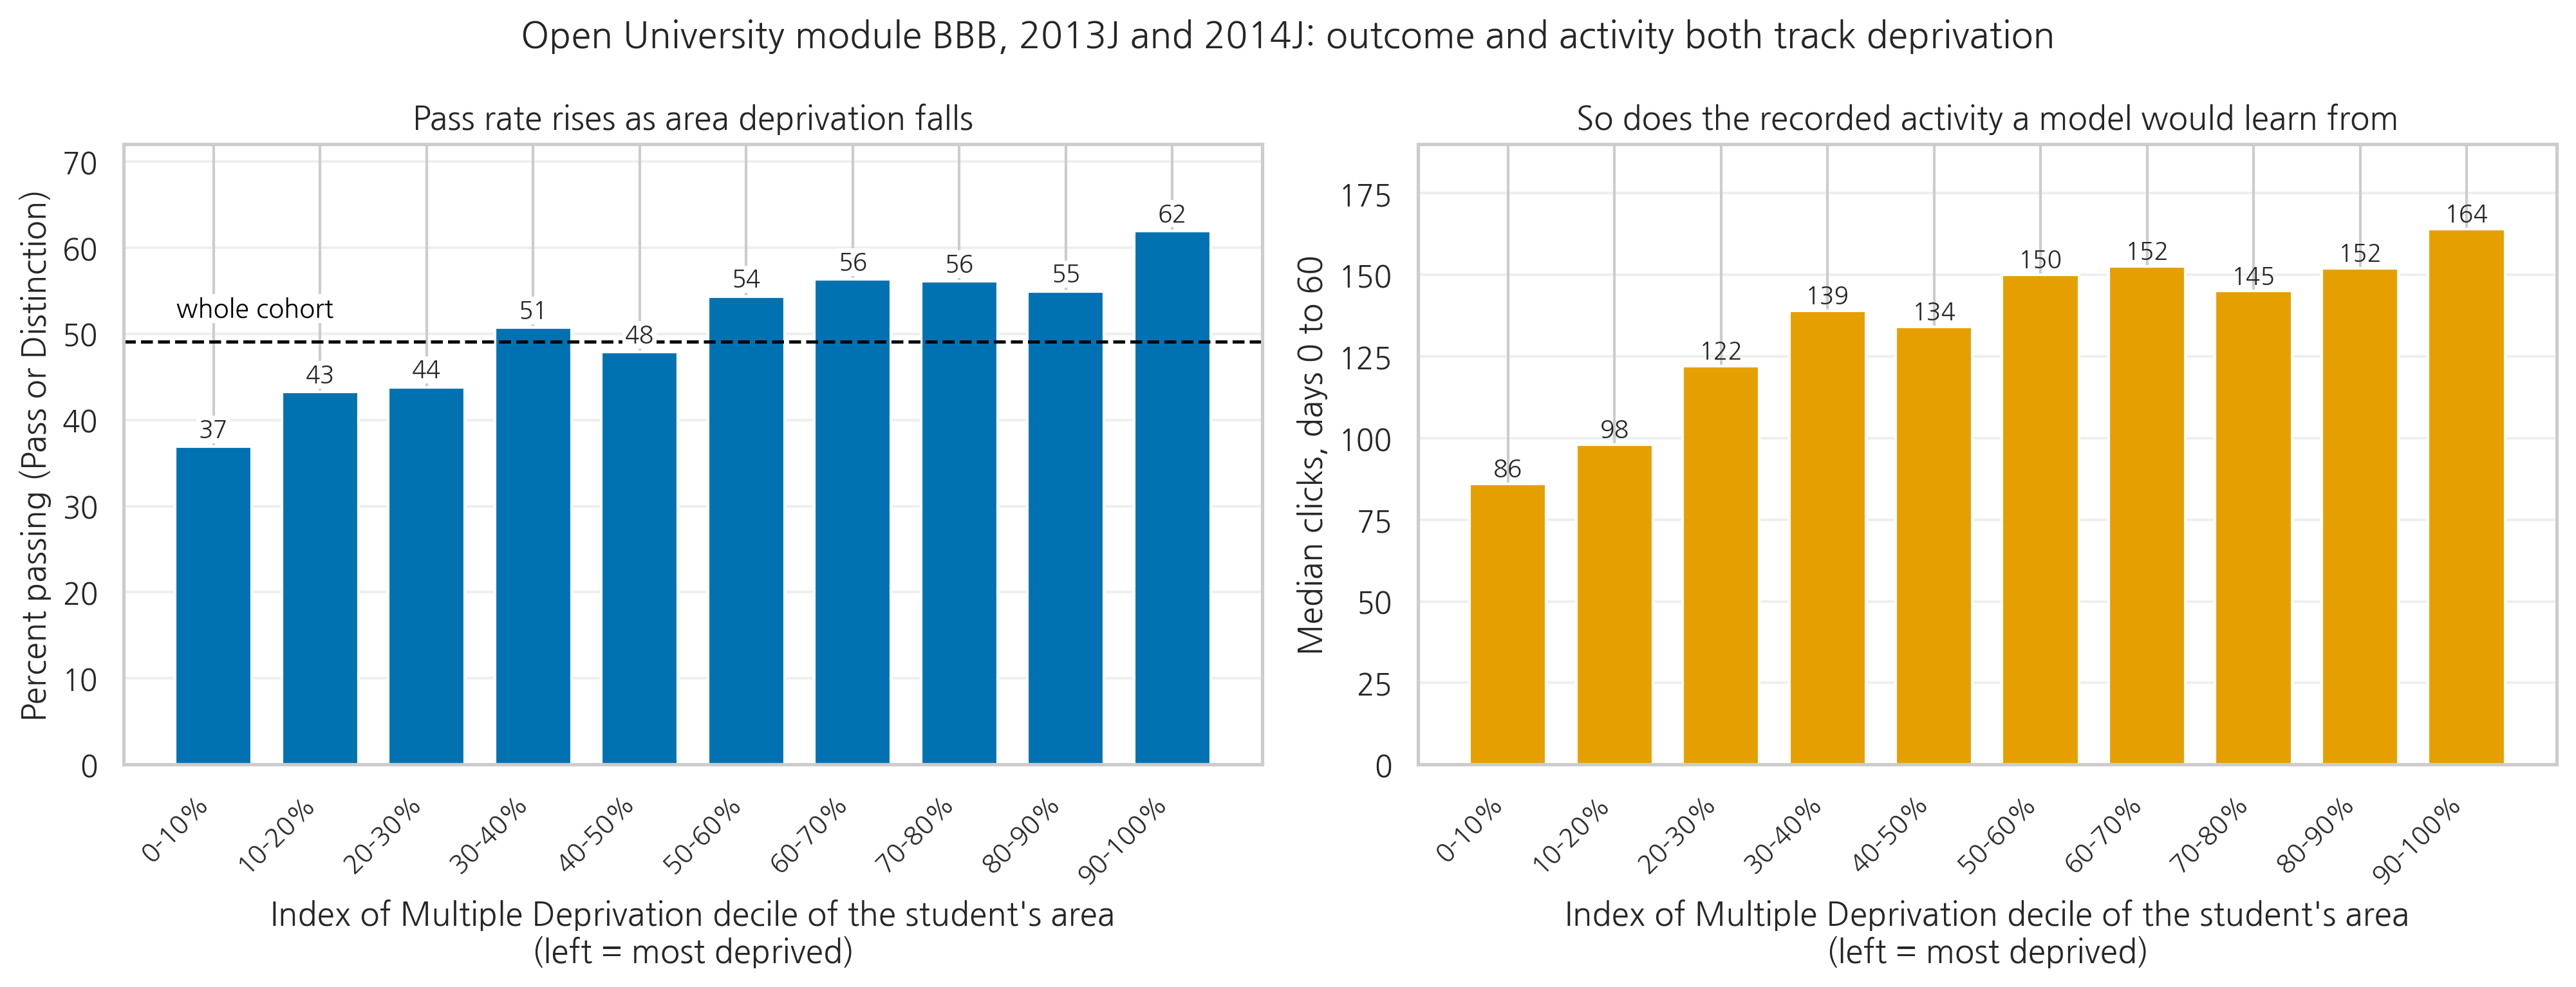

In [4]:
data["passed"] = 1 - data["did_not_pass"]

BLUE, ORANGE, GREEN = "#0072B2", "#E69F00", "#009E73"

by_imd = (data.groupby("imd_band_clean")
          .agg(students=("passed", "size"),
               pass_rate=("passed", "mean"),
               median_clicks=("clicks", "median"),
               median_active_days=("active_days", "median"))
          .reindex(IMD_ORDER + ["Not recorded"]))

print("PASS RATE AND ACTIVITY BY DEPRIVATION DECILE (0-10% = most deprived areas)")
show = by_imd.copy()
show["pass_rate"] = (show["pass_rate"] * 100).round(1)
print(show.to_string())

by_dis = (data.groupby("disability")
          .agg(students=("passed", "size"),
               pass_rate=("passed", "mean"),
               median_clicks=("clicks", "median")))
print("\nPASS RATE AND ACTIVITY BY RECORDED DISABILITY")
show2 = by_dis.copy()
show2["pass_rate"] = (show2["pass_rate"] * 100).round(1)
print(show2.to_string())

print(f"\nWhole cohort pass rate: {data['passed'].mean():.1%}")
print(f"Most deprived decile {by_imd.loc['0-10%', 'pass_rate']:.1%}  "
      f"vs least deprived decile {by_imd.loc['90-100%', 'pass_rate']:.1%}")
print(f"Disability recorded {by_dis.loc['Y', 'pass_rate']:.1%}  "
      f"vs not recorded {by_dis.loc['N', 'pass_rate']:.1%}")

# ---------------------------------------------------------------- figure 1
grad = by_imd.loc[IMD_ORDER]
xpos = np.arange(len(IMD_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

label_box = dict(facecolor="white", edgecolor="none", pad=0.9)
axes[0].bar(xpos, grad["pass_rate"] * 100, color=BLUE, width=0.72)
axes[0].axhline(data["passed"].mean() * 100, color="black", linestyle="--", linewidth=1.2)
axes[0].text(-0.35, data["passed"].mean() * 100 + 3.0, "whole cohort",
             ha="left", fontsize=9.5, color="black", bbox=label_box)
for i, v in enumerate(grad["pass_rate"] * 100):
    axes[0].text(i, v + 1.2, f"{v:.0f}", ha="center", fontsize=9, bbox=label_box)
axes[0].set_ylabel("Percent passing (Pass or Distinction)")
axes[0].set_title("Pass rate rises as area deprivation falls")
axes[0].set_ylim(0, 72)

axes[1].bar(xpos, grad["median_clicks"], color=ORANGE, width=0.72)
for i, v in enumerate(grad["median_clicks"]):
    axes[1].text(i, v + 2.5, f"{v:.0f}", ha="center", fontsize=9)
axes[1].set_ylabel(f"Median clicks, days 0 to {CHECKPOINT_DAY}")
axes[1].set_title("So does the recorded activity a model would learn from")
axes[1].set_ylim(0, 190)

for ax in axes:
    ax.set_xticks(xpos)
    ax.set_xticklabels(IMD_ORDER, rotation=45, ha="right", fontsize=9.5)
    ax.set_xlabel("Index of Multiple Deprivation decile of the student's area\n(left = most deprived)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Open University module BBB, 2013J and 2014J: outcome and activity both track deprivation",
             fontsize=13.5)
fig.tight_layout()
plt.show()

**Read the two panels together, because that is where the problem lives.**

The left panel is an outcome gap. The right panel is a gap in the thing we are about to hand a model as evidence.

**Say what these panels are evidence about, before you say anything else.** A gradient across deprivation deciles is a measurement of the conditions under which people studied, and of an institution that produced different outcomes for people in different circumstances. It is not a measurement of the people. Nothing here licenses a sentence of the form "students from deprived areas are less X." The Index of Multiple Deprivation is an area-level index: it describes a few hundred neighbouring households, not a person, and assigning it to an individual is the ecological fallacy we agreed to commit on purpose because it is what the column offers and what institutions actually do.

What the left panel measures, concretely, is that this module returned a pass to 37 percent of the enrollments from the most deprived tenth of areas and 62 percent from the least deprived tenth. That is a fact about a module, a university, a support structure, a fee regime, and a labour market. The intervention it implies is at that level too.

The right panel then adds the part that makes this an ethics session rather than a sociology one. If recorded activity is lower in the most deprived decile, and pass rates are also lower there, a model trained on recorded activity will learn a relationship that is partly about learning and partly about the cost of studying: broadband at home, a quiet room, a laptop nobody else needs, hours not sold to an employer, a shift pattern that does not produce evenly spaced clicks.

**Discuss before you run anything else:** the model we are about to build will never see `imd_band`. Does that make it blind to deprivation, or just unable to tell you that it is not?

**One caution on the right panel.** The gradient is not perfectly monotonic. The 40-50% decile sits below 30-40%, and 70-80% sits below 60-70%. With between 268 and 591 students per decile, a couple of bands out of order is what real sampling noise looks like. A story that requires every bar to be taller than the last is a story you should not tell.

## 📊 3. Train the model, then read the accuracy honestly

**Logistic regression in one sentence.** It finds the best available dividing line between the enrollments that ended in `Fail` or `Withdrawn` and the ones that did not, and hands back, for each enrollment, a number between 0 and 1 that behaves like a predicted probability of that outcome. Notice what that number is not: it is not a property of a person, and it is not a probability about anybody's future. It is this model's guess at a registry field, fitted on people who finished the module two years before the person being scored enrolled.

The feature set is deliberately ordinary. It is close to what a vendor early warning product actually uses, because click data is what a virtual learning environment exports without anyone having to ask permission:

`clicks` (how much), `active_days` (how regularly), `resources` (how widely)

Three decisions inside the next cell deserve to be said out loud, because in a deployed system nobody sees them.

**How we test it.** Five-fold cross validation: split the cohort into five parts, train on four, predict the fifth, rotate until every student has been scored by a model that never saw their outcome. Scoring a model on the students it trained on is grading your own homework.

**How a score becomes an action.** A predicted probability does nothing by itself. Somebody has to decide who gets contacted. Our rule is the simplest one available: flag every enrollment whose score is at least 0.5. That 0.5 is not a statistical quantity, it is an operating decision, and you will get to move it in a minute.

**What "good" would even mean.** The honest comparison is not zero. It is the best thing you could do with no model at all. Here that is "never flag anybody," which is right about every student who passed and wrong about everybody else.

In [5]:
y_true = data["did_not_pass"].to_numpy()

def predicted_scores(feature_names):
    """Fit a logistic regression and return an out-of-sample predicted probability
    of did_not_pass, one per enrollment.

    Every score comes from a model trained on the other four folds, so no enrollment
    is ever scored by a model that already saw how that enrollment ended.
    """
    X = data[list(feature_names)].to_numpy(dtype=float)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=8100)
    return cross_val_predict(model, X, y_true, cv=folds, method="predict_proba")[:, 1]

def flag_at(scores, threshold):
    """Turn a predicted probability into an action: who does the advising office contact?"""
    return (scores >= threshold).astype(int)

THRESHOLD = 0.5
ACTIVITY_FEATURES = ["clicks", "active_days", "resources"]

scores_activity = predicted_scores(ACTIVITY_FEATURES)
flags_activity = flag_at(scores_activity, THRESHOLD)

accuracy_activity = (flags_activity == y_true).mean()
do_nothing = (y_true == 0).mean()        # accuracy of "never flag anybody"
flag_everyone = (y_true == 1).mean()     # accuracy of "flag the whole cohort"

print(f"Features            : {', '.join(ACTIVITY_FEATURES)}")
print(f"Enrollments scored  : {len(data):,}")
print(f"Flagged at {THRESHOLD:.2f}      : {int(flags_activity.sum()):,} enrollments "
      f"({flags_activity.mean():.1%} of the cohort)\n")
print(f"Model accuracy              : {accuracy_activity:.3f}")
print(f"'Never flag anybody'        : {do_nothing:.3f}")
print(f"'Flag the whole cohort'     : {flag_everyone:.3f}")
print(f"\nThe model beats doing nothing by {accuracy_activity - do_nothing:.3f}, "
      f"which is {(accuracy_activity - do_nothing) * len(data):.0f} enrollments' worth of extra")
print("correct classifications. Note the word: classifications, not help.")

Features            : clicks, active_days, resources
Enrollments scored  : 4,529
Flagged at 0.50      : 2,381 enrollments (52.6% of the cohort)

Model accuracy              : 0.735
'Never flag anybody'        : 0.491
'Flag the whole cohort'     : 0.509

The model beats doing nothing by 0.244, which is 1105 enrollments' worth of extra
correct classifications. Note the word: classifications, not help.


**Pause here.** The model is right about roughly three enrollments in four, and it beats the do-nothing rule by a wide margin. In week 1's invented course the do-nothing rule was hard to beat. Here it is not, because roughly half of these enrollments did not end in a pass, so the outcome the model is looking for is not rare.

**Would you deploy this? What would you want to know first?**

Notice that everything you have seen so far is a single number describing 4,529 people at once. A single number cannot tell you who absorbed the mistakes.

## 📊 4. The audit: who pays for the mistakes?

An overall accuracy number averages over everybody, which is exactly what makes it comfortable. To audit a model you break the errors apart and count each kind inside each group.

There are two ways to be wrong, and they land on different people:

| Error | Plain language | What it costs the student |
|---|---|---|
| **False positive** | Flagged, but the enrollment went on to pass | Being watched, advised at, or labeled when nothing in the record needed it |
| **False negative** | Not flagged, and the enrollment did not pass | Being invisible to a system built to help you |

So we compute three numbers inside each group:

- **False positive rate**: of the enrollments in this group that **did** pass, what share did the model flag anyway?
- **False negative rate**: of the enrollments in this group that **did not** pass, what share did the model miss?
- **Share flagged**: of everyone in this group, what share got a flag at all? This is the number the person experiences. It does not care whether the flag turned out to be correct.

These are proportions, so 0.30 means three in ten.

**A warning to read before the table, not after.** We are about to compute three rates in each of ten deciles, which is thirty numbers, and then a reader's eye will go straight to the largest and the smallest of them. That is thirty chances for noise to produce something that looks like a finding. The denominators here run from 102 to 373, so each rate carries a standard error of roughly three percentage points, and the *range* across ten such cells is around 0.09 to 0.10 even when every decile shares exactly the same true rate. The notebook prints that comparison so you can check it rather than take it on trust.

The defensible move is not to hunt for the biggest cell-to-cell gap. It is to ask whether the rates **trend** across the deciles, which is one question rather than ten, and to put an interval on the trend. That is what the cell below does.

ACTIVITY-ONLY MODEL, audited by deprivation decile
              enrollments  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                                           
0-10%                 591         218                0.317               373                0.201          0.621
10-20%                557         241                0.320               316                0.241          0.569
20-30%                566         248                0.278               318                0.261          0.537
30-40%                495         251                0.267               244                0.258          0.501
40-50%                474         227                0.286               247                0.271          0.517
50-60%                449         244                0.266               205                0.259          0.483
60-70%                412         232        

  false positive rate    -0.0032   95% [-0.0100, +0.0036]   no detectable trend


  false negative rate    +0.0023   95% [-0.0040, +0.0084]   no detectable trend


  share flagged          -0.0141   95% [-0.0193, -0.0088]   trend detected


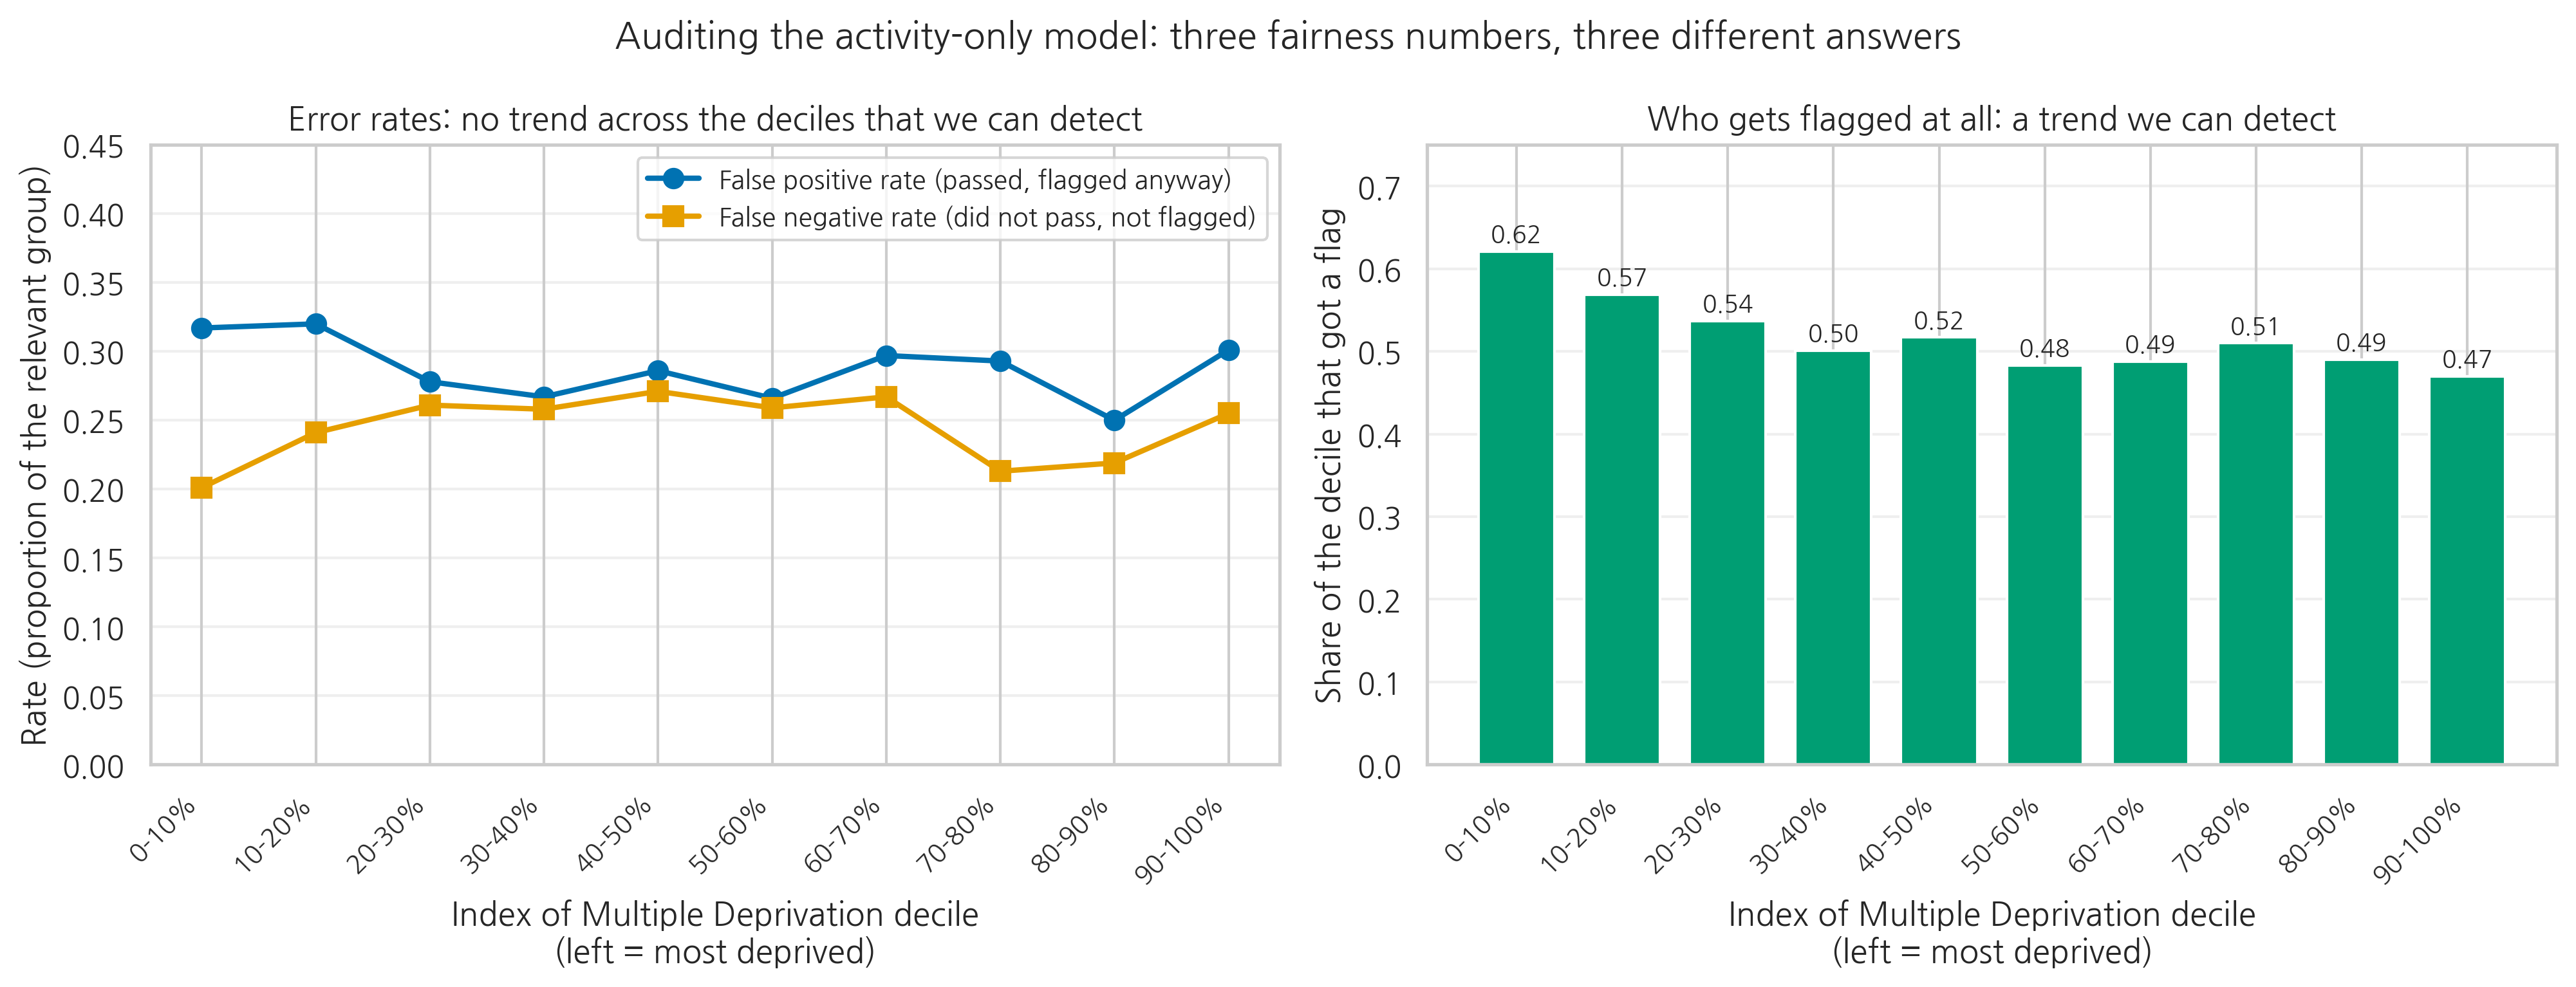

In [6]:
def audit_table(flags, groups):
    """False positive rate, false negative rate, and share flagged inside each group."""
    rows = []
    for name, mask in groups.items():
        passed_here = mask & (y_true == 0)       # in this group, the enrollment passed
        not_passed_here = mask & (y_true == 1)   # in this group, it did not
        rows.append({
            "group": name,
            "enrollments": int(mask.sum()),
            "passed (n)": int(passed_here.sum()),
            "false positive rate": round(float(flags[passed_here].mean()), 3) if passed_here.sum() else np.nan,
            "did not pass (n)": int(not_passed_here.sum()),
            "false negative rate": round(float(1 - flags[not_passed_here].mean()), 3) if not_passed_here.sum() else np.nan,
            "share flagged": round(float(flags[mask].mean()), 3),
        })
    return pd.DataFrame(rows).set_index("group")


IMD_GROUPS = {band: (data["imd_band_clean"] == band).to_numpy()
              for band in IMD_ORDER + ["Not recorded"]}
DISABILITY_GROUPS = {
    "Disability recorded":     (data["disability"] == "Y").to_numpy(),
    "No disability recorded":  (data["disability"] == "N").to_numpy(),
}

audit_imd_activity = audit_table(flags_activity, IMD_GROUPS)
audit_dis_activity = audit_table(flags_activity, DISABILITY_GROUPS)

print("ACTIVITY-ONLY MODEL, audited by deprivation decile")
print(audit_imd_activity.to_string())
print("\nACTIVITY-ONLY MODEL, audited by recorded disability")
print(audit_dis_activity.to_string())

# ---------------------------------------------------------------------------
# Ten deciles is ten comparisons. Two guards against reading noise as a finding.
# ---------------------------------------------------------------------------
DECILE_X = np.arange(1, 11)
audit_rng = np.random.default_rng(8100)


def decile_series(flags, column):
    """The ten decile rates for one column, plus the denominator each rests on."""
    tbl = audit_table(flags, IMD_GROUPS).loc[IMD_ORDER]
    denom = {"false positive rate": "passed (n)",
             "false negative rate": "did not pass (n)",
             "share flagged": "enrollments"}[column]
    return tbl[column].to_numpy(), tbl[denom].to_numpy()


def gradient(flags, column):
    """Weighted least squares slope of the rate on decile number: one number, one test."""
    ys, ns = decile_series(flags, column)
    return float(np.polyfit(DECILE_X, ys, 1, w=np.sqrt(ns))[0])


def gradient_interval(flags, column, n_boot=2000):
    """Bootstrap the gradient by resampling enrollments inside each decile."""
    idx = {b: np.where(IMD_GROUPS[b])[0] for b in IMD_ORDER}
    draws = []
    for _ in range(n_boot):
        ys, ns = [], []
        for b in IMD_ORDER:
            s = audit_rng.choice(idx[b], idx[b].size)
            fl, yy = flags[s], y_true[s]
            if column == "false positive rate":
                keep = yy == 0
                v = fl[keep].mean()
            elif column == "false negative rate":
                keep = yy == 1
                v = 1 - fl[keep].mean()
            else:
                keep = np.ones(s.size, dtype=bool)
                v = fl.mean()
            ys.append(v)
            ns.append(keep.sum())
        draws.append(np.polyfit(DECILE_X, ys, 1, w=np.sqrt(ns))[0])
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return gradient(flags, column), float(lo), float(hi)


def noise_range(flags, column, n_sim=4000):
    """If all ten deciles shared ONE true rate, how big would max minus min be anyway?"""
    ys, ns = decile_series(flags, column)
    p = float(np.average(ys, weights=ns))
    sims = np.array([[audit_rng.binomial(n, p) / n for n in ns] for _ in range(n_sim)])
    spans = sims.max(axis=1) - sims.min(axis=1)
    return float(ys.max() - ys.min()), float(spans.mean()), np.percentile(spans, [2.5, 97.5])


print("\nTHIRTY NUMBERS, TEN DECILES: how much of the spread is just noise?")
print("(the 'if the deciles were identical' column is a simulation, not a guess)")
print(f"  {'':<22}{'observed range':>16}{'if identical':>15}{'  95% of the time within'}")
for column in ["false positive rate", "false negative rate", "share flagged"]:
    obs, mean_span, ci = noise_range(flags_activity, column)
    print(f"  {column:<22}{obs:>16.3f}{mean_span:>15.3f}   [{ci[0]:.3f}, {ci[1]:.3f}]")

print("\nTHE GRADIENT: one question instead of ten, with a 95 percent bootstrap interval")
print("(change in the rate per one-decile step, from most deprived to least)")
for column in ["false positive rate", "false negative rate", "share flagged"]:
    point, lo, hi = gradient_interval(flags_activity, column)
    verdict = "no detectable trend" if lo < 0 < hi else "trend detected"
    print(f"  {column:<22} {point:+.4f}   95% [{lo:+.4f}, {hi:+.4f}]   {verdict}")

fpr_col = audit_imd_activity.loc[IMD_ORDER, "false positive rate"]
sel_col = audit_imd_activity.loc[IMD_ORDER, "share flagged"]
fnr_col = audit_imd_activity.loc[IMD_ORDER, "false negative rate"]

# ---------------------------------------------------------------- figure 2
xpos = np.arange(len(IMD_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

axes[0].plot(xpos, fpr_col.to_numpy(), marker="o", markersize=7, linewidth=2,
             color=BLUE, label="False positive rate (passed, flagged anyway)")
axes[0].plot(xpos, fnr_col.to_numpy(), marker="s", markersize=7, linewidth=2,
             color=ORANGE, label="False negative rate (did not pass, not flagged)")
axes[0].set_ylim(0, 0.45)
axes[0].set_ylabel("Rate (proportion of the relevant group)")
axes[0].set_title("Error rates: no trend across the deciles that we can detect")
axes[0].legend(loc="upper right", fontsize=9.5)

axes[1].bar(xpos, sel_col.to_numpy(), color=GREEN, width=0.72)
for i, v in enumerate(sel_col.to_numpy()):
    axes[1].text(i, v + 0.012, f"{v:.2f}", ha="center", fontsize=9)
axes[1].set_ylim(0, 0.75)
axes[1].set_ylabel("Share of the decile that got a flag")
axes[1].set_title("Who gets flagged at all: a trend we can detect")

for ax in axes:
    ax.set_xticks(xpos)
    ax.set_xticklabels(IMD_ORDER, rotation=45, ha="right", fontsize=9.5)
    ax.set_xlabel("Index of Multiple Deprivation decile\n(left = most deprived)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Auditing the activity-only model: three fairness numbers, three different answers",
             fontsize=13.5)
fig.tight_layout()
plt.show()


**Read the chart before you read this paragraph.** Look at the left panel, then the right panel, then decide for yourself whether this model has a fairness problem.

Here is what the two panels are arguing about.

By **error rates**, this model looks close to even, and now you have the arithmetic to say so properly rather than by eye. The false positive rate wanders between 0.25 and 0.32 across the ten deciles, but the printout shows that ten cells of this size would produce a spread of about that much even if every decile shared one identical true rate. The gradient, which is one question instead of ten, comes out at about three thousandths of a point per decile step with a bootstrap interval straddling zero. Same for the false negative rate. If a fairness report said "we checked for equalized odds across deprivation deciles and found no detectable disparity," it would not be lying.

By **who gets flagged**, the same model is a long way from even, and this one survives every guard we just built. The observed spread is 0.151 where noise alone would give about 0.075, and the gradient is about minus 0.014 per decile step with an interval nowhere near zero. Enrollments in the most deprived decile get flagged at more than 0.6, in the least deprived at under 0.5.

Both statements are true about the same 4,529 enrollments and the same set of predictions. They differ because the recorded pass rate differs so much across the deciles: when the outcome a model is looking for is more common in a group, the model can spread its errors evenly and still send far more letters there.

This is not a trick. It is a known mathematical fact about fairness metrics, and it is the concrete version of what **Holstein and Doroudi (2022)** are pressing on. A fairness metric does not tell you whether a system is fair. It tells you which question you asked. Somebody chose which one goes in the report.

**Discuss:** the advising office has to write one sentence about this model in a memo to the provost. Write that sentence twice, once so the model sounds fine and once so it sounds alarming, using only true statements from the output above. Then argue about which one you would actually send, and notice that the honest version of the alarming sentence is about who receives letters, not about who receives errors.

### The same discipline, applied to a single comparison

The decile cell above put an interval on a *trend*. The disability column is a single two-group comparison, so it gets a single interval.

Before we say anything about it, we should find out whether we are allowed to. There are 412 enrollments with a recorded disability against 4,117 without, so any rate we compute for the first group rests on a much smaller pile.

The next cell resamples the enrollments 2,000 times with replacement and reports the range that 95 percent of those resamples fall in. If that range comfortably contains zero, the difference we are looking at is inside what random variation would produce anyway, and saying it out loud without the interval would be a lie of confidence.

One limit of this particular bootstrap, said out loud because it is the kind of thing that gets left out: it resamples the people the model was *evaluated* on, holding the fitted model fixed. It therefore describes how much the measured rates would wobble on another sample of students, not how much they would wobble if the whole pipeline were refitted. The real uncertainty is a little wider than what prints below.

In [7]:
rng = np.random.default_rng(8100)

def gap_with_interval(flags, mask_a, mask_b, kind, n_boot=2000):
    """Difference in one error rate between two groups, plus a bootstrap interval.

    kind="fpr" restricts to enrollments that passed; kind="fnr" to those that did not.
    """
    if kind == "fpr":
        a, b = mask_a & (y_true == 0), mask_b & (y_true == 0)
        rate = lambda idx: flags[idx].mean()
    elif kind == "fnr":
        a, b = mask_a & (y_true == 1), mask_b & (y_true == 1)
        rate = lambda idx: 1 - flags[idx].mean()
    else:                                   # "sel": share of the whole group flagged
        a, b = mask_a, mask_b
        rate = lambda idx: flags[idx].mean()
    ia, ib = np.where(a)[0], np.where(b)[0]
    point = rate(ia) - rate(ib)
    draws = np.array([rate(rng.choice(ia, ia.size)) - rate(rng.choice(ib, ib.size))
                      for _ in range(n_boot)])
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return point, lo, hi

has_dis = DISABILITY_GROUPS["Disability recorded"]
no_dis = DISABILITY_GROUPS["No disability recorded"]

print("DISABILITY GAP IN THE ACTIVITY-ONLY MODEL, with 95 percent bootstrap intervals")
print("(positive means the rate is worse for students with a recorded disability)\n")
dis_gaps = {}
for kind, label in [("fpr", "false positive rate"), ("fnr", "false negative rate")]:
    point, lo, hi = gap_with_interval(flags_activity, has_dis, no_dis, kind)
    dis_gaps[kind] = (point, lo, hi)
    verdict = "straddles zero" if lo < 0 < hi else "does not contain zero"
    print(f"  {label:<22} gap {point:+.3f}   95% interval [{lo:+.3f}, {hi:+.3f}]   {verdict}")

n_fp_dis = int(flags_activity[has_dis & (y_true == 0)].sum())
n_ok_dis = int((has_dis & (y_true == 0)).sum())
print(f"\n  Those rates rest on {n_fp_dis} false positives out of {n_ok_dis} enrollments that "
      f"passed\n  and carried a recorded disability. Always print the denominator.")

# for contrast: the outcome gap itself, which is not subtle
p_dis = data.loc[data["disability"] == "Y", "passed"].mean()
p_nodis = data.loc[data["disability"] == "N", "passed"].mean()
print(f"\nFor contrast, the gap the audit is NOT measuring:")
print(f"  pass rate {p_dis:.1%} with a recorded disability vs {p_nodis:.1%} without, "
      f"a gap of {(p_nodis - p_dis) * 100:.1f} percentage points.")
print("  That one is about the module and what it did or did not make possible.")

DISABILITY GAP IN THE ACTIVITY-ONLY MODEL, with 95 percent bootstrap intervals
(positive means the rate is worse for students with a recorded disability)

  false positive rate    gap +0.015   95% interval [-0.055, +0.091]   straddles zero
  false negative rate    gap +0.041   95% interval [-0.016, +0.101]   straddles zero

  Those rates rest on 50 false positives out of 166 enrollments that passed
  and carried a recorded disability. Always print the denominator.

For contrast, the gap the audit is NOT measuring:
  pass rate 40.3% with a recorded disability vs 50.0% without, a gap of 9.7 percentage points.
  That one is about the module and what it did or did not make possible.


**This is the most important cell in the notebook, and it has no chart.**

The model's error rates for enrollments with a recorded disability are slightly worse than for everyone else, and the intervals straddle zero. Resting on 166 enrollments that passed, we cannot tell that difference from noise. The honest report is "no detectable disparity in error rates," and reporting the point estimate alone, as if it were a finding, would be the kind of confident fragile claim this course keeps asking you to refuse.

Now hold that next to the last line the cell printed. The **outcome** gap by disability is close to ten percentage points, on thousands of enrollments, and it is not fragile at all.

Read that outcome gap the way section 2 taught you to read the deprivation gradient. `disability` in this file records a bureaucratic event: somebody disclosed, to a system they had to know about and trust, with paperwork. A ten point pass-rate gap attached to that column is evidence about what this module and this university made possible for people who disclosed, and about who was able to disclose at all. It is not evidence about the people.

So the audit came back clean on a group whose recorded experience of this module was measurably worse. That is not a failure of arithmetic. It is a statement about what an error-rate audit is for. It asks "does the model treat these groups differently," not "is the situation these groups are in different." **Holstein and Doroudi (2022)** would say the second question is the one an institution owes an answer to, and it is the one our audit is structurally incapable of asking.

**Discuss:** if you were writing the equity section of a report on this system, would you include the disability audit at all? What does including it risk, and what does leaving it out risk?

## ✏️ Your turn 1: the number that is not in the model

`THRESHOLD` decides who gets contacted. It is not a property of the algorithm and there is no statistical procedure that sets it. Somebody picks it, usually based on how many phone calls the advising office can make.

The cell below already works, so you can just run it. Then change `0.5` to something else (try `0.3`, then `0.7`) and re-run **this cell only**. Nothing later in the notebook depends on it, so you cannot break anything.

Watch two things as you move it: how many enrollments get flagged, and what happens to the gap between the most and least deprived deciles. The cell prints a bootstrap interval next to each gap, because a three-decimal number with no interval beside it is an invitation to over-read.

In [8]:
MY_THRESHOLD = 0.5    # ✏️ change this number, then re-run this cell (try 0.3, then 0.7)

flags_try = flag_at(scores_activity, MY_THRESHOLD)
table_try = audit_table(flags_try, IMD_GROUPS).loc[["0-10%", "90-100%"]]

overall_fnr = 1 - flags_try[y_true == 1].mean()
print(f"Threshold {MY_THRESHOLD:.2f}  ->  {int(flags_try.sum()):,} enrollments flagged "
      f"({flags_try.mean():.1%} of the cohort), overall accuracy {(flags_try == y_true).mean():.3f}")
print(f"Across the whole cohort this misses {overall_fnr:.1%} of the enrollments that did "
      f"not end in a pass.\n")
print(table_try[["passed (n)", "false positive rate",
                 "did not pass (n)", "false negative rate", "share flagged"]].to_string())

print("\nMost deprived decile minus least deprived, with 95 percent bootstrap intervals:")
for column, kind in [("false positive rate", "fpr"),
                     ("false negative rate", "fnr"),
                     ("share flagged", "sel")]:
    point, lo, hi = gap_with_interval(flags_try, IMD_GROUPS["0-10%"],
                                      IMD_GROUPS["90-100%"], kind)
    verdict = "straddles zero" if lo < 0 < hi else "does not contain zero"
    print(f"  {column:<22} {point:+.3f}   95% [{lo:+.3f}, {hi:+.3f}]   {verdict}")
print("\nOnly one of those three survives its interval at any threshold you would use.")

Threshold 0.50  ->  2,381 enrollments flagged (52.6% of the cohort), overall accuracy 0.735
Across the whole cohort this misses 24.4% of the enrollments that did not end in a pass.

         passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                         
0-10%           218                0.317               373                0.201          0.621
90-100%         166                0.301               102                0.255          0.470

Most deprived decile minus least deprived, with 95 percent bootstrap intervals:
  false positive rate    +0.015   95% [-0.078, +0.111]   straddles zero
  false negative rate    -0.054   95% [-0.144, +0.043]   straddles zero


  share flagged          +0.151   95% [+0.082, +0.222]   does not contain zero

Only one of those three survives its interval at any threshold you would use.


## 📊 5. Redesign round: change what the model is allowed to look at

Here is the move that matters, and it is smaller than people expect.

We are **not** going to change the algorithm. Logistic regression was never the problem. It did what it was asked to do, on the numbers it was given, competently. We are going to change **what we let it look at.**

That is a design decision. Design decisions have authors, they get written down, and somebody with the authority to revise them can revise them on a Tuesday afternoon. That is a very different kind of object from "the algorithm is biased."

Out go `active_days` and `resources`. Both describe the **shape of somebody's week**: how many separate calendar squares have something in them, how far they roamed. Somebody holding down a job studies in two long blocks instead of six short ones. Same reading, same effort, fewer squares. Part 2 of this notebook shows that mechanism working, on data where we can read it off the generator instead of arguing about it.

In come three columns about **what a student produced and how it was judged** by day 60:

- `n_submitted`: how many of the assignments due by day 60 they handed in
- `mean_score`: their average mark on those, with the cohort median filled in for anyone who submitted nothing
- `no_submission`: 1 if that fill happened, so the model can tell an average student from an absent one

`clicks` stays, because volume of work is not the same thing as shape of schedule.

## ✏️ Your turn 2: pick the feature set

The line in the next cell already contains a set that works, so run it as it is first. Then add or remove one column name and re-run to see what your choice does.

Columns you can choose from:

`clicks`, `active_days`, `resources`, `n_submitted`, `mean_score`, `no_submission`, `no_activity`, `num_of_prev_attempts`, `studied_credits`

Two questions worth holding while you choose:

1. Does this feature describe something the student **did**, or something their **circumstances** did to them?
2. If a student were told this column was being used to decide whether they get a phone call, would they feel supported or surveilled?

You may not use `imd_band` or `disability`. Not because it would be technically hard, but because "should a protected attribute ever be a model input" is a live argument with good people on both sides, and it deserves more than a spare line in a code cell. Bring it to the discussion block instead.

Activity-only features : clicks, active_days, resources
  accuracy 0.735, flagged 2,381
Redesigned features    : clicks, n_submitted, mean_score, no_submission
  accuracy 0.788, flagged 1,712

REDESIGNED MODEL, audited by deprivation decile
              enrollments  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                                           
0-10%                 591         218                0.087               373                0.292          0.479
10-20%                557         241                0.120               316                0.326          0.434
20-30%                566         248                0.093               318                0.308          0.429
30-40%                495         251                0.080               244                0.385          0.343
40-50%                474         227                0.062               247     


WHAT CHANGED OVERALL (whole cohort, no subgroups yet)
                              activity-only   redesigned
  false positive rate                 0.287        0.082
  false negative rate                 0.244        0.337
  share flagged                       0.526        0.378
  accuracy                            0.735        0.788

  accuracy gain, redesigned minus activity-only: +0.0532   95% [+0.0395, +0.0658]

WHAT CHANGED ACROSS THE DECILES: the gradient, with 95 percent bootstrap intervals
(rate change per one-decile step. Ranges are not reported: with ten cells this size
 a range of about 0.09 appears even when every decile shares one identical rate.)


  false positive rate    activity-only -0.0032 [-0.0103, +0.0037]   redesigned -0.0040 [-0.0083, +0.0001]


  false negative rate    activity-only +0.0023 [-0.0038, +0.0083]   redesigned +0.0044 [-0.0025, +0.0115]


  share flagged          activity-only -0.0141 [-0.0195, -0.0091]   redesigned -0.0183 [-0.0236, -0.0136]

AND THE ONE COMPARISON THAT MATTERS: did the redesign flatten the flag gradient?


  change in the share-flagged gradient, redesigned minus activity-only: -0.0042   95% [-0.0088, +0.0003]
  A negative number means steeper, not flatter. Read the interval before the point.

WHAT CHANGED, BY RECORDED DISABILITY (with 95 percent bootstrap intervals)
  false positive rate    activity-only +0.015 [-0.055, +0.091]   redesigned -0.004 [-0.043, +0.038]
  false negative rate    activity-only +0.041 [-0.016, +0.101]   redesigned +0.014 [-0.048, +0.076]


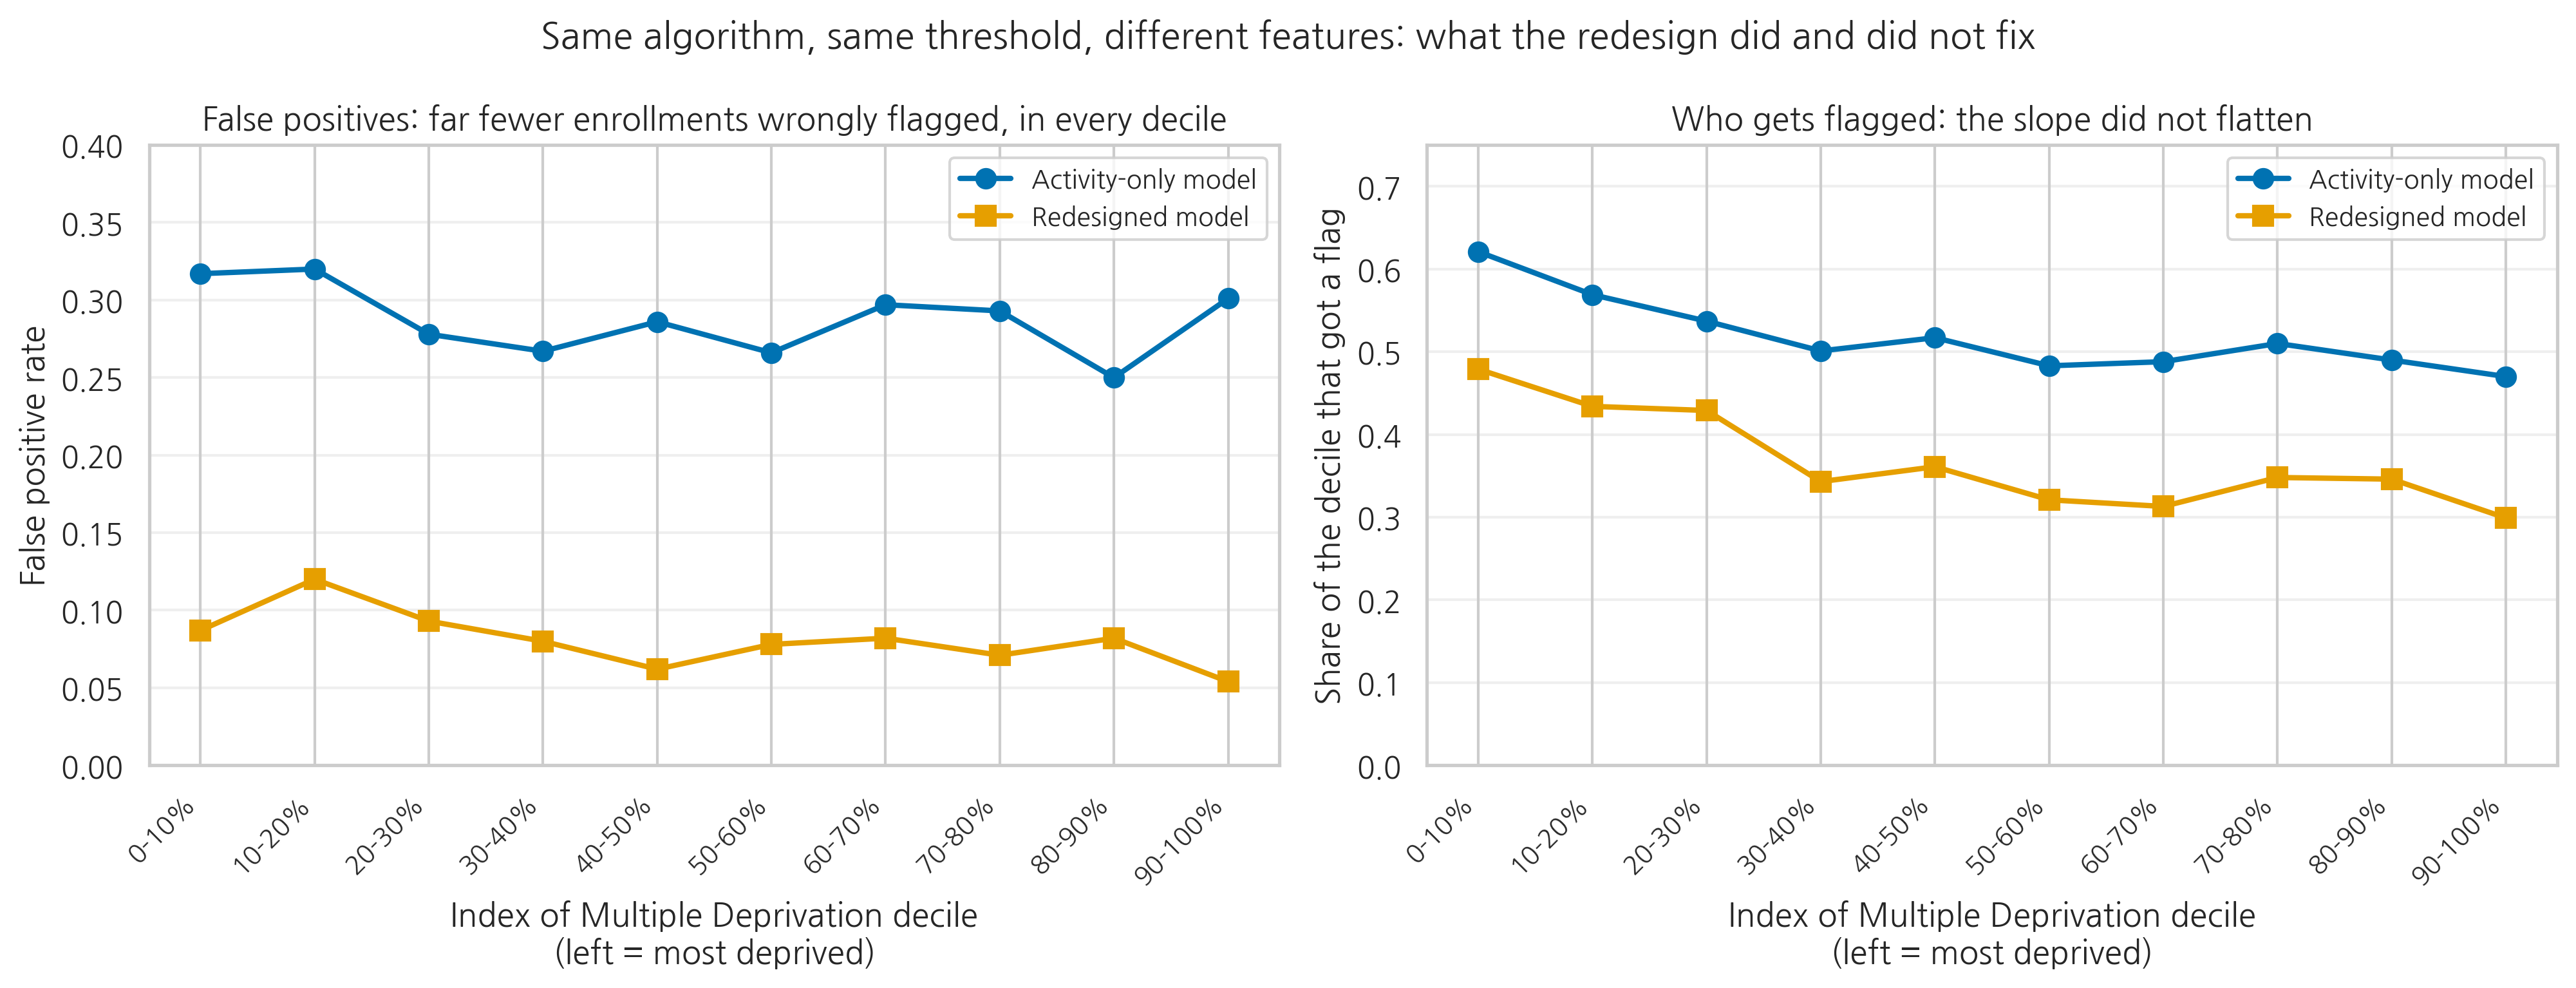

In [9]:
# ✏️ TODO: choose the features for the redesigned model.
#          The default below already works. Change it once you have run it as is.
my_features = ["clicks", "n_submitted", "mean_score", "no_submission"]


# --- a friendly safety net: unknown or forbidden names fall back to the default ---
DEFAULT_REDESIGN = ["clicks", "n_submitted", "mean_score", "no_submission"]
ALLOWED = ["clicks", "active_days", "resources", "n_submitted", "mean_score",
           "no_submission", "no_activity", "num_of_prev_attempts", "studied_credits"]

usable = [c for c in my_features if c in ALLOWED]
if len(usable) != len(my_features) or not usable:
    rejected = [c for c in my_features if c not in ALLOWED]
    print(f"Heads up: {rejected} is not on the list, so we used the default set instead.")
    print(f"Choose from: {', '.join(ALLOWED)}\n")
    usable = DEFAULT_REDESIGN

REDESIGN_FEATURES = usable
scores_redesign = predicted_scores(REDESIGN_FEATURES)
flags_redesign = flag_at(scores_redesign, THRESHOLD)
accuracy_redesign = (flags_redesign == y_true).mean()

audit_imd_redesign = audit_table(flags_redesign, IMD_GROUPS)
audit_dis_redesign = audit_table(flags_redesign, DISABILITY_GROUPS)

print(f"Activity-only features : {', '.join(ACTIVITY_FEATURES)}")
print(f"  accuracy {accuracy_activity:.3f}, flagged {int(flags_activity.sum()):,}")
print(f"Redesigned features    : {', '.join(REDESIGN_FEATURES)}")
print(f"  accuracy {accuracy_redesign:.3f}, flagged {int(flags_redesign.sum()):,}\n")

print("REDESIGNED MODEL, audited by deprivation decile")
print(audit_imd_redesign.to_string())
print("\nREDESIGNED MODEL, audited by recorded disability")
print(audit_dis_redesign.to_string())

_acc_draws = []
for _ in range(2000):
    _s = audit_rng.integers(0, len(y_true), len(y_true))
    _acc_draws.append((flags_redesign[_s] == y_true[_s]).mean()
                      - (flags_activity[_s] == y_true[_s]).mean())
_acc_lo, _acc_hi = np.percentile(_acc_draws, [2.5, 97.5])

print("\nWHAT CHANGED OVERALL (whole cohort, no subgroups yet)")
print(f"  {'':<26}{'activity-only':>15}{'redesigned':>13}")
for label, fn in [("false positive rate", lambda f: f[y_true == 0].mean()),
                  ("false negative rate", lambda f: 1 - f[y_true == 1].mean()),
                  ("share flagged", lambda f: f.mean()),
                  ("accuracy", lambda f: (f == y_true).mean())]:
    print(f"  {label:<26}{fn(flags_activity):>15.3f}{fn(flags_redesign):>13.3f}")
print(f"\n  accuracy gain, redesigned minus activity-only: "
      f"{accuracy_redesign - accuracy_activity:+.4f}   95% [{_acc_lo:+.4f}, {_acc_hi:+.4f}]")

print("\nWHAT CHANGED ACROSS THE DECILES: the gradient, with 95 percent bootstrap intervals")
print("(rate change per one-decile step. Ranges are not reported: with ten cells this size")
print(" a range of about 0.09 appears even when every decile shares one identical rate.)")
for column in ["false positive rate", "false negative rate", "share flagged"]:
    pa, la, ha = gradient_interval(flags_activity, column)
    pr, lr, hr = gradient_interval(flags_redesign, column)
    print(f"  {column:<22} activity-only {pa:+.4f} [{la:+.4f}, {ha:+.4f}]   "
          f"redesigned {pr:+.4f} [{lr:+.4f}, {hr:+.4f}]")

print("\nAND THE ONE COMPARISON THAT MATTERS: did the redesign flatten the flag gradient?")
_g_idx = {b: np.where(IMD_GROUPS[b])[0] for b in IMD_ORDER}


def _flag_slope(flags, sample):
    ys = [flags[sample[b]].mean() for b in IMD_ORDER]
    ws = np.sqrt([len(sample[b]) for b in IMD_ORDER])
    return np.polyfit(DECILE_X, ys, 1, w=ws)[0]


_point = _flag_slope(flags_redesign, _g_idx) - _flag_slope(flags_activity, _g_idx)
_draws = []
for _ in range(2000):
    _s = {b: audit_rng.choice(_g_idx[b], _g_idx[b].size) for b in IMD_ORDER}
    _draws.append(_flag_slope(flags_redesign, _s) - _flag_slope(flags_activity, _s))
_lo, _hi = np.percentile(_draws, [2.5, 97.5])
print(f"  change in the share-flagged gradient, redesigned minus activity-only: "
      f"{_point:+.4f}   95% [{_lo:+.4f}, {_hi:+.4f}]")
print("  A negative number means steeper, not flatter. Read the interval before the point.")

print("\nWHAT CHANGED, BY RECORDED DISABILITY (with 95 percent bootstrap intervals)")
for kind, label in [("fpr", "false positive rate"), ("fnr", "false negative rate")]:
    pa, la, ha = dis_gaps[kind]
    pr, lr, hr = gap_with_interval(flags_redesign, has_dis, no_dis, kind)
    print(f"  {label:<22} activity-only {pa:+.3f} [{la:+.3f}, {ha:+.3f}]   "
          f"redesigned {pr:+.3f} [{lr:+.3f}, {hr:+.3f}]")

# ---------------------------------------------------------------- figure 3
xpos = np.arange(len(IMD_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

axes[0].plot(xpos, audit_imd_activity.loc[IMD_ORDER, "false positive rate"], marker="o",
             markersize=7, linewidth=2, color=BLUE, label="Activity-only model")
axes[0].plot(xpos, audit_imd_redesign.loc[IMD_ORDER, "false positive rate"], marker="s",
             markersize=7, linewidth=2, color=ORANGE, label="Redesigned model")
axes[0].set_ylim(0, 0.40)
axes[0].set_ylabel("False positive rate")
axes[0].set_title("False positives: far fewer enrollments wrongly flagged, in every decile")

axes[1].plot(xpos, audit_imd_activity.loc[IMD_ORDER, "share flagged"], marker="o",
             markersize=7, linewidth=2, color=BLUE, label="Activity-only model")
axes[1].plot(xpos, audit_imd_redesign.loc[IMD_ORDER, "share flagged"], marker="s",
             markersize=7, linewidth=2, color=ORANGE, label="Redesigned model")
axes[1].set_ylim(0, 0.75)
axes[1].set_ylabel("Share of the decile that got a flag")
axes[1].set_title("Who gets flagged: the slope did not flatten")

for ax in axes:
    ax.set_xticks(xpos)
    ax.set_xticklabels(IMD_ORDER, rotation=45, ha="right", fontsize=9.5)
    ax.set_xlabel("Index of Multiple Deprivation decile\n(left = most deprived)")
    ax.legend(loc="upper right", fontsize=9.5)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Same algorithm, same threshold, different features: what the redesign did and did not fix",
             fontsize=13.5)
fig.tight_layout()
plt.show()

### What changed, and what did not

**What changed, and it is not nothing.** Accuracy went up, not down, from 0.735 to 0.788, and that improvement is large relative to its uncertainty: bootstrapped over enrollments, the gain is about +0.053 with a 95 percent interval of roughly [+0.040, +0.066]. The overall false positive rate fell from 0.287 to 0.082, which is thousands of letters not sent to people whose enrollments went on to pass. The disability gap in false positives, already indistinguishable from noise, moved to the other side of zero and stayed indistinguishable from noise. The usual argument against auditing a model is that fairness costs accuracy. Here it did not.

**What we specifically cannot say.** We cannot say the redesign narrowed the *spread* of false positive rates across the deciles, and the notebook no longer prints that comparison, because it was never a real quantity. Ten cells of this size produce a max-minus-min of about 0.09 by chance alone, and both models' observed spreads sit inside that. The same is true of the false negative spread. Any sentence that compares two of those ranges is comparing two draws from noise. Reporting it would have been the most persuasive wrong thing in this notebook, which is exactly why it is worth deleting out loud rather than quietly.

**What did not change.** Look at the right panel again, and at the gradient print-out. The share-flagged gradient was about minus 0.014 per decile step before the redesign and about minus 0.018 after it, both with intervals nowhere near zero, and the change between them has an interval that includes zero. So the honest sentence is: **the redesign did not flatten the flag gradient, and if anything it steepened it, though we cannot show the steepening exceeds noise.** Enrollments in the most deprived decile are still flagged far more often than those in the least deprived.

**And one thing got worse in a way we can measure.** The overall false negative rate rose from 0.244 to 0.337. The redesigned model flags far fewer enrollments, so it misses more of the ones that did not end in a pass. Fewer false alarms was never free. It was paid for in people who might have wanted a call and did not get one. That is a whole-cohort number with a large denominator, which is why it can be stated while the decile-by-decile version of it cannot.

**Sit with why the gradient held.** In a course exercise the story usually ends with the gap collapsing and everybody feeling better. Here it did not collapse, and the reason is not that we chose bad features. It is that the outcome gradient is real: enrollments from the most deprived decile of this module ended in `Fail` or `Withdrawn` at much higher rates than enrollments from the least deprived one. Read that the way section 2 asked you to. It is a measurement of the conditions people studied under and of what this institution made possible, not of the people. A model that ranks enrollments by their probability of that outcome, and is any good at all, will flag that group more often, because it is fitting a real pattern in the institution's own records. You cannot feature-engineer your way out of an unequal world, and a model that stopped flagging them would not be fairer, it would be worse at its stated job while also being less useful to the people it stopped naming.

So the audit has taken you somewhere uncomfortable and correct. Some of what was in the left panel was the feature set, and we fixed that part, decisively. What remains is the module, the university, the labour market, and the housing stock, and no feature list touches it.

**Discuss with your neighbour:** you now have two models. One scores 0.735 and flags 2,381 enrollments, most of a cohort. One scores 0.788, flags 1,712, and misses more of the enrollments that did not end in a pass. Both send disproportionately many letters to the poorest tenth. If the first had been running for three years with a vendor contract attached, what would it actually take, inside a real university, to switch? And is switching the most useful thing anyone in this story could do?

### Three cautions before this feels like a solution

**One. `mean_score` is not innocent either.** An early mark carries the history of every school a student attended before this one, and those schools were not equally resourced or equally forgiving. Swapping a feature that partly encodes "how many hours you work for pay" for a feature that partly encodes "which school you went to" is a trade, not a fix. It moves the harm somewhere our audit was not looking.

**Two. We audited two attributes because we suspected them, and we still made thirty comparisons doing it.** `imd_band` and `disability`. A gap you never measured is not a gap you fixed, and a gap you found by scanning thirty cells for the biggest one is not a gap either. This dataset also carries `age_band`, `gender`, `region`, and `highest_education`, and it carries nothing at all about caring responsibilities, illness, immigration status, or whether the broadband works.

**Three. We audited a model, not an intervention.** A warm, well-staffed outreach conversation and an automatic "academic concern" note in a person's permanent file are the same flag attached to very different consequences. **Lee and Gargroetzi (2023)** interviewed mentors who received exactly this kind of information about the students they were supporting and found them genuinely ambivalent about holding it. Nobody in this notebook asked the 4,529 students whether they wanted to be scored at all.

Week 4 puts a model like this on a dashboard and asks what a teacher would do with it. Keep this list.

## 📊 6. What our one big decision actually bought us

Back in section 1 we decided to keep the 836 enrollments with no clicks recorded in the first 60 days, rather than dropping them. (738 have no click anywhere in the file; narrowing to the window adds 98 more.) That was the right call, and it is also the reason the accuracy number above looks as good as it does.

Most of those enrollments had already formally unregistered before day 60. The registry knew. Our model is being congratulated for rediscovering something the university had already written down.

The next cell reruns the whole thing on only the enrollments **still registered** at day 60, which is the population an early warning system would actually be scoring. Nothing else changes.

In [10]:
still_here = data["date_unregistration"].isna() | (data["date_unregistration"] > CHECKPOINT_DAY)
gone_already = ~still_here
silent_and_gone = int((gone_already & (data["no_activity"] == 1)).sum())
print(f"Of the {int(data['no_activity'].sum()):,} enrollments with zero clicks in the window, "
      f"{silent_and_gone:,} had already formally unregistered by day {CHECKPOINT_DAY}.")
print(f"In total {int(gone_already.sum()):,} enrollments had unregistered by then.\n")

subset = data[still_here].reset_index(drop=True)
y_subset = subset["did_not_pass"].to_numpy()

X = subset[ACTIVITY_FEATURES].to_numpy(dtype=float)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=8100)
subset_scores = cross_val_predict(model, X, y_subset, cv=folds, method="predict_proba")[:, 1]
subset_flags = (subset_scores >= THRESHOLD).astype(int)

print(f"{'':<44}{'everyone':>12}{'still registered':>19}")
print(f"{'enrollments scored':<44}{len(data):>12,}{len(subset):>19,}")
print(f"{'share that ended in Fail or Withdrawn':<44}{y_true.mean():>12.3f}{y_subset.mean():>19.3f}")
print(f"{'accuracy of the activity-only model':<44}{accuracy_activity:>12.3f}"
      f"{(subset_flags == y_subset).mean():>19.3f}")
print(f"{chr(34) + 'never flag anybody' + chr(34):<44}{do_nothing:>12.3f}{(y_subset == 0).mean():>19.3f}")
print(f"\nDropped by this rule: {len(data) - len(subset):,} enrollments who had already unregistered by day "
      f"{CHECKPOINT_DAY}.")
gain_all = accuracy_activity - do_nothing
gain_sub = (subset_flags == y_subset).mean() - (y_subset == 0).mean()
print(f"\nHow far the model beats doing nothing:")
print(f"  with everyone included     {gain_all:+.3f}")
print(f"  still-registered students  {gain_sub:+.3f}")

Of the 836 enrollments with zero clicks in the window, 712 had already formally unregistered by day 60.
In total 1,006 enrollments had unregistered by then.

                                                everyone   still registered
enrollments scored                                 4,529              3,523
share that ended in Fail or Withdrawn              0.509              0.369
accuracy of the activity-only model                0.735              0.692
"never flag anybody"                               0.491              0.631

Dropped by this rule: 1,006 enrollments who had already unregistered by day 60.

How far the model beats doing nothing:
  with everyone included     +0.244
  still-registered students  +0.061


**Look at the last two lines.** Against everyone, the model looks like a substantial improvement over doing nothing. Against the students it would actually be scoring, the improvement is much smaller, because most of the easy cases were students the university had already lost.

Neither column is the honest one on its own. The first is honest about the module: half of these enrollments ended badly and that is the phenomenon. The second is honest about the tool: an early warning system that runs on day 60 cannot help someone who unregistered on day 20.

**This is the reporting decision, and it is yours to make.** Which of those two accuracy numbers goes in the abstract? Notice that a vendor has one obvious preference, and that the more flattering number is not the false one. It is just the one that answers a question nobody was asking.

**Discuss:** what would you have to say alongside the accuracy figure for a reader to know which population it describes?

## ✏️ Your turn 3 (stretch): audit a group nobody asked about

The gaps we found were ones we went looking for. This cell points the same audit at any column of the roster.

`age_band` is the working default, so the cell runs as it is. Try `gender`, `highest_education`, or `region`, and note what happens to the size of the cells you are comparing.

One rule carries over from section 4 and it is the whole point of the exercise: the more columns you point this at, the more cells you generate, and the more likely it is that the largest number you find is noise. Before you report anything from this cell, write down how many comparisons you made to find it.

In [11]:
AUDIT_COLUMN = "age_band"   # ✏️ try "gender", "highest_education", or "region"

if AUDIT_COLUMN not in data.columns:
    print(f"'{AUDIT_COLUMN}' is not a column in this table, so we used 'age_band' instead.\n")
    AUDIT_COLUMN = "age_band"

custom_groups = {
    f"{AUDIT_COLUMN} = {value}": (data[AUDIT_COLUMN] == value).to_numpy()
    for value in sorted(data[AUDIT_COLUMN].dropna().unique())
}

print(f"ACTIVITY-ONLY MODEL, audited by {AUDIT_COLUMN}")
print(audit_table(flags_activity, custom_groups).to_string())
print(f"\nREDESIGNED MODEL, audited by {AUDIT_COLUMN}")
print(audit_table(flags_redesign, custom_groups).to_string())
print("\nA small 'passed (n)' or 'did not pass (n)' means the rate above it is fragile.")
print("Say so out loud before you report it, the way we did for the disability column.")

ACTIVITY-ONLY MODEL, audited by age_band
                  enrollments  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                                               
age_band = 0-35          2987        1363                0.341              1624                0.224          0.578
age_band = 35-55         1535         858                0.200               677                0.291          0.425
age_band = 55<=             7           3                0.333                 4                0.500          0.429

REDESIGNED MODEL, audited by age_band
                  enrollments  passed (n)  false positive rate  did not pass (n)  false negative rate  share flagged
group                                                                                                               
age_band = 0-35          2987        1363                0.098              1624                0.331

---

# 🎯 Part 2: the same audit, on data whose mechanism was written down

You have just done everything an audit can do on real data, and it left you with an argument rather than an answer. Enrollments in the most deprived decile get flagged far more often. Some of what the audit found came from the feature set, and we removed that part. The gradient came from somewhere, and the dataset cannot tell you where.

That is not a limitation of your skills. It is what observational data is.

So now we do something a course can do and a research paper usually cannot: run the same audit on the synthetic course from weeks 1 and 2, **where the mechanism is not a hypothesis, because somebody typed it.**

`EDUC 1010: Learning How to Learn` is 120 invented undergraduates at an invented university. The next cell builds them. Inside the generator, two lines decide everything you are about to see:

```python
# from make_clickstream(): how likely a student is to touch the course on a given day
p_active = _sigmoid(0.45 + 0.95 * regularity_z)
p_active = np.where(concentrated == 1, p_active * 0.18, p_active)

# from make_gradebook(): what actually drives their quiz scores
base = (76.0 + 7.2 * ability + 1.9 * srl_z + 0.3 * engagement
        + 4.2 * regularity_z - 4.1 * procrast_z - 0.6 * burst + noise)
```

Read them as sentences. A latent trait called `regularity` raises both how many separate days somebody touches the course and how well they score. Separately, being a first generation student who works 15 or more hours a week (`concentrated` in the generator's variable names) multiplies the chance of appearing on any given day by **0.18**, and moves the score itself by **0.6 points**, which is nothing.

In other words: working long hours compresses the week into fewer days and leaves the learning almost untouched. That is not a finding. It is a design specification, and we can check the model against it.

One caution about the variable name before we use it. The generator calls this group `concentrated_schedule`, and this notebook says "first generation students who work 15 or more hours a week" instead, because that is what defines the group in the code. "Burst worker" is a name for a study pattern that follows from a work schedule, and it would travel out of the notebook as a name for a kind of person. It is worth noticing that even in invented data, the variable name was the first place a description of circumstances turned into a description of people.

## ⚙️ Setup for Part 2: run the next cell

The cell below is the course data generator, pasted in so this notebook works in Colab with no downloads. It is long on purpose and you do not need to read it. Collapse it with the arrow at its left edge, run it once, and move on.

It writes three small CSV files into this runtime: `students.csv`, `lms_clickstream.csv`, and `gradebook.csv`. Nothing leaves your machine.

In [12]:
# This cell is long on purpose. It is the data generator for the synthetic course,
# pasted in so that this notebook works in Colab with no downloads and no accounts.
# You do not need to read it. Collapse it with the arrow on the left, run it once,
# and move on to section 7.

"""EDIS 8100 data generation, the subset needed for week03.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_CLICKSTREAM = SEED + 1
SEED_GRADEBOOK = SEED + 2
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    deadline_proximity = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the activity-only model in week 3 leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the activity-only model in week 3 misread them.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    concentrated_schedule = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (concentrated_schedule == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid succession, faster than anyone could read one.
    rapid_hint_runs = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    rapid_hint_runs[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "deadline_proximity": deadline_proximity,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "concentrated_schedule": concentrated_schedule,
            "rapid_hint_runs": rapid_hint_runs,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
EVENT_TYPES = [
    "login", "page_view", "video_play", "video_pause",
    "forum_view", "assignment_view", "submit",
]
EVENT_BASE_P = np.array([0.12, 0.32, 0.16, 0.11, 0.13, 0.11, 0.05])
def make_clickstream(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """LMS event log for the eight course weeks.

    Two things vary across students and they are not the same thing. Volume is how
    many events a student generates, and it is heavy tailed. Regularity is how many
    separate days they show up at all. The week also has a rhythm: Monday and
    Tuesday spike ahead of the Tuesday night quiz deadline.

    Two subgroups break the "more clicks means more learning" story. Efficient
    students generate few events and score well (P1). First generation students
    working 15+ hours can only touch the course on a handful of days, so their
    regularity looks terrible even though their learning does not (P2).
    """
    rng = np.random.default_rng(SEED_CLICKSTREAM)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    proximity = students["deadline_proximity"].to_numpy()
    regularity_z = _z(students["regularity"].to_numpy())
    efficient = students["efficient"].to_numpy()
    concentrated = students["concentrated_schedule"].to_numpy()

    # Expected event count per student, lognormal so the tail is heavy.
    log_mu = (
        5.78
        + 0.40 * engagement
        + 0.05 * ability
        + 0.10 * regularity_z
        + np.log(np.where(efficient == 1, 0.30, 1.0))
        + np.log(np.where(concentrated == 1, 0.95, 1.0))
    )
    n_events = np.clip(
        np.round(np.exp(log_mu + rng.normal(0, 0.18, n))), 25, 4000
    ).astype(int)

    n_days = N_WEEKS * 7
    day_index = np.arange(n_days)
    weekday = (day_index + 0) % 7  # 0 = Monday, because 2026-09-07 is a Monday
    weekday_weight = np.array([1.45, 1.60, 1.10, 1.00, 0.75, 0.60, 1.05])
    weekday_rel = weekday_weight / weekday_weight.mean()
    week_of = day_index // 7
    week_weight = 1.0 - 0.022 * week_of  # attention fades a little across the term
    base_day_w = weekday_weight[weekday] * week_weight

    # Probability that a given student touches the course on a given day.
    p_active = _sigmoid(0.45 + 0.95 * regularity_z)
    # Working 15+ hours compresses the week into a couple of long evenings.
    p_active = np.where(concentrated == 1, p_active * 0.18, p_active)

    # Submit events crowd into the 48 hours before each Tuesday deadline.
    submit_day_w = np.where(np.isin(weekday, [0, 1]), 5.0, 0.70) * week_weight

    rows_student, rows_day, rows_type = [], [], []
    rows_hour = []

    for i in range(n):
        k = int(n_events[i])
        day_p = np.clip(p_active[i] * weekday_rel[weekday] * week_weight, 0.01, 0.97)
        active = rng.random(n_days) < day_p
        if active.sum() < 4:
            active[rng.choice(n_days, size=4, replace=False)] = True

        w = base_day_w * active * (0.55 + rng.gamma(3.0, 1.0 / 3.0, n_days))
        w = w / w.sum()
        sw = submit_day_w * active
        sw = sw / sw.sum()

        # Per-student taste for videos versus pages versus the forum.
        p_types = rng.dirichlet(EVENT_BASE_P * 55.0)
        types = rng.choice(len(EVENT_TYPES), size=k, p=p_types)

        days = rng.choice(n_days, size=k, p=w)
        is_submit = types == EVENT_TYPES.index("submit")
        if is_submit.any():
            days[is_submit] = rng.choice(n_days, size=int(is_submit.sum()), p=sw)

        # Time of day: three loose study sessions, later for procrastinators.
        centers = rng.choice(
            [9.6, 14.2, 20.8], size=k, p=[0.27, 0.33, 0.40]
        ) + 1.05 * proximity[i] * rng.random(k)
        hours = centers + rng.normal(0, 0.85, k)
        hours = np.clip(hours, 0.02, 23.97)

        rows_student.append(np.full(k, i))
        rows_day.append(days)
        rows_type.append(types)
        rows_hour.append(hours)

    student_idx = np.concatenate(rows_student)
    days = np.concatenate(rows_day)
    types = np.concatenate(rows_type)
    hours = np.concatenate(rows_hour)

    seconds = days * DAY_S + hours * 3600.0
    order = np.argsort(seconds, kind="stable")
    student_idx, days, types, seconds = (
        student_idx[order], days[order], types[order], seconds[order]
    )

    week = (days // 7 + 1).astype(int)
    type_names = np.array(EVENT_TYPES)[types]

    # Plausible resource ids per event type.
    resource = np.empty(seconds.size, dtype=object)
    page_no = rng.integers(1, 9, seconds.size)
    video_no = rng.integers(1, 5, seconds.size)
    thread_no = rng.integers(1, 61, seconds.size)
    for t, name in enumerate(EVENT_TYPES):
        mask = types == t
        if not mask.any():
            continue
        if name == "login":
            resource[mask] = "lms_home"
        elif name == "page_view":
            resource[mask] = [
                f"w{w}_page_{p:02d}" for w, p in zip(week[mask], page_no[mask])
            ]
        elif name in ("video_play", "video_pause"):
            resource[mask] = [
                f"w{w}_video_{v:02d}" for w, v in zip(week[mask], video_no[mask])
            ]
        elif name == "forum_view":
            resource[mask] = [f"thread_{t3:03d}" for t3 in thread_no[mask]]
        else:  # assignment_view and submit both point at the next quiz due
            deadline_days = np.array([QUIZ_DEADLINE_DAY[k] for k in range(1, N_WEEKS + 1)])
            next_quiz = np.clip(
                1 + np.searchsorted(deadline_days, days[mask], side="left"), 1, N_WEEKS
            )
            resource[mask] = [f"quiz_{k}" for k in next_quiz]

    df = pd.DataFrame(
        {
            "event_id": [f"E{i + 1:06d}" for i in range(seconds.size)],
            "student_id": students["student_id"].to_numpy()[student_idx],
            "timestamp": _iso(_ts(seconds)),
            "week": week,
            "event_type": type_names,
            "resource_id": resource,
        }
    )
    if write:
        df.to_csv(_outpath(outdir, "lms_clickstream.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks deadline_proximity, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    proximity = students["deadline_proximity"].to_numpy()
    rapid_hint_runs = students["rapid_hint_runs"].to_numpy()
    concentrated = students["concentrated_schedule"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(proximity)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * concentrated
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * rapid_hint_runs + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: some students submit close to the deadline.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_clickstream(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir

In [13]:
build_data("data")

synth_students = pd.read_csv("data/students.csv")
synth_clicks = pd.read_csv("data/lms_clickstream.csv", parse_dates=["timestamp"])
synth_grades = pd.read_csv("data/gradebook.csv")

synth_clicks["day"] = synth_clicks["timestamp"].dt.date
synth_activity = synth_clicks.groupby("student_id").agg(
    total_events=("event_id", "count"),
    active_days=("day", "nunique"),
)
synth_quiz = (synth_grades[synth_grades["assessment"].str.startswith("quiz")]
              .groupby("student_id")["score"].mean().rename("mean_quiz"))

synth = (synth_students.set_index("student_id")
         .join(synth_activity).join(synth_quiz).reset_index())
# The outcome for Part 2. "below_70" says what it is: a mean quiz score under a line
# somebody chose. It is not a description of a student.
QUIZ_LINE = 70
synth["below_70"] = (synth["mean_quiz"] < QUIZ_LINE).astype(int)

print(f"Synthetic course built: {len(synth)} students, "
      f"{len(synth_clicks):,} clickstream events, {len(synth_grades):,} gradebook rows.")
print(f"Mean quiz below the chosen line of {QUIZ_LINE}: {int(synth['below_70'].sum())} students "
      f"({synth['below_70'].mean():.1%})")

Synthetic course built: 120 students, 41,117 clickstream events, 1,080 gradebook rows.
Mean quiz below the chosen line of 70: 34 students (28.3%)


## 📊 7. Run the audit again, on the invented course

Exactly the same machinery: logistic regression, five-fold cross validation, flag everyone scoring 0.5 or above. Only the data changed.

The group we audit is the one the generator built: the 30 students who are first generation **and** work 15 or more hours a week.

Two things to hold before the numbers land. First, the outcome here is `below_70`, meaning a mean quiz score under 70, and 70 is a line somebody typed, exactly as arbitrary as the 60 in week 1. Second, this is 120 students. Every subgroup rate below rests on tens of people, sometimes on single-digit counts of events, so the cell prints the counts and a Fisher exact p-value next to every proportion. The point of Part 2 is not that the audit is cleaner here. It is that the *mechanism* is knowable here, which is a different thing, and section 8 is where we go and read it.

Activity-only features (total_events, active_days): accuracy 0.733, flagged 14
Redesigned features (prior_gpa, total_events)     : accuracy 0.833, flagged 28
'Never flag anybody'                              : accuracy 0.717

Notice the first line against the third: on this invented course the activity-only
model barely beats flagging nobody at all. It is a weak model, and weak models
produce fragile subgroup rates. Read every proportion below next to its counts.

ACTIVITY-ONLY MODEL on the synthetic course
                          students  scored 70+ (n)  false positives  false positive rate  scored under 70 (n)  false negative rate  flagged  share flagged
group                                                                                                                                                     
First gen, works 15+ hrs        30              21                4                0.190                    9                0.333       10          0.333
Everyone else         

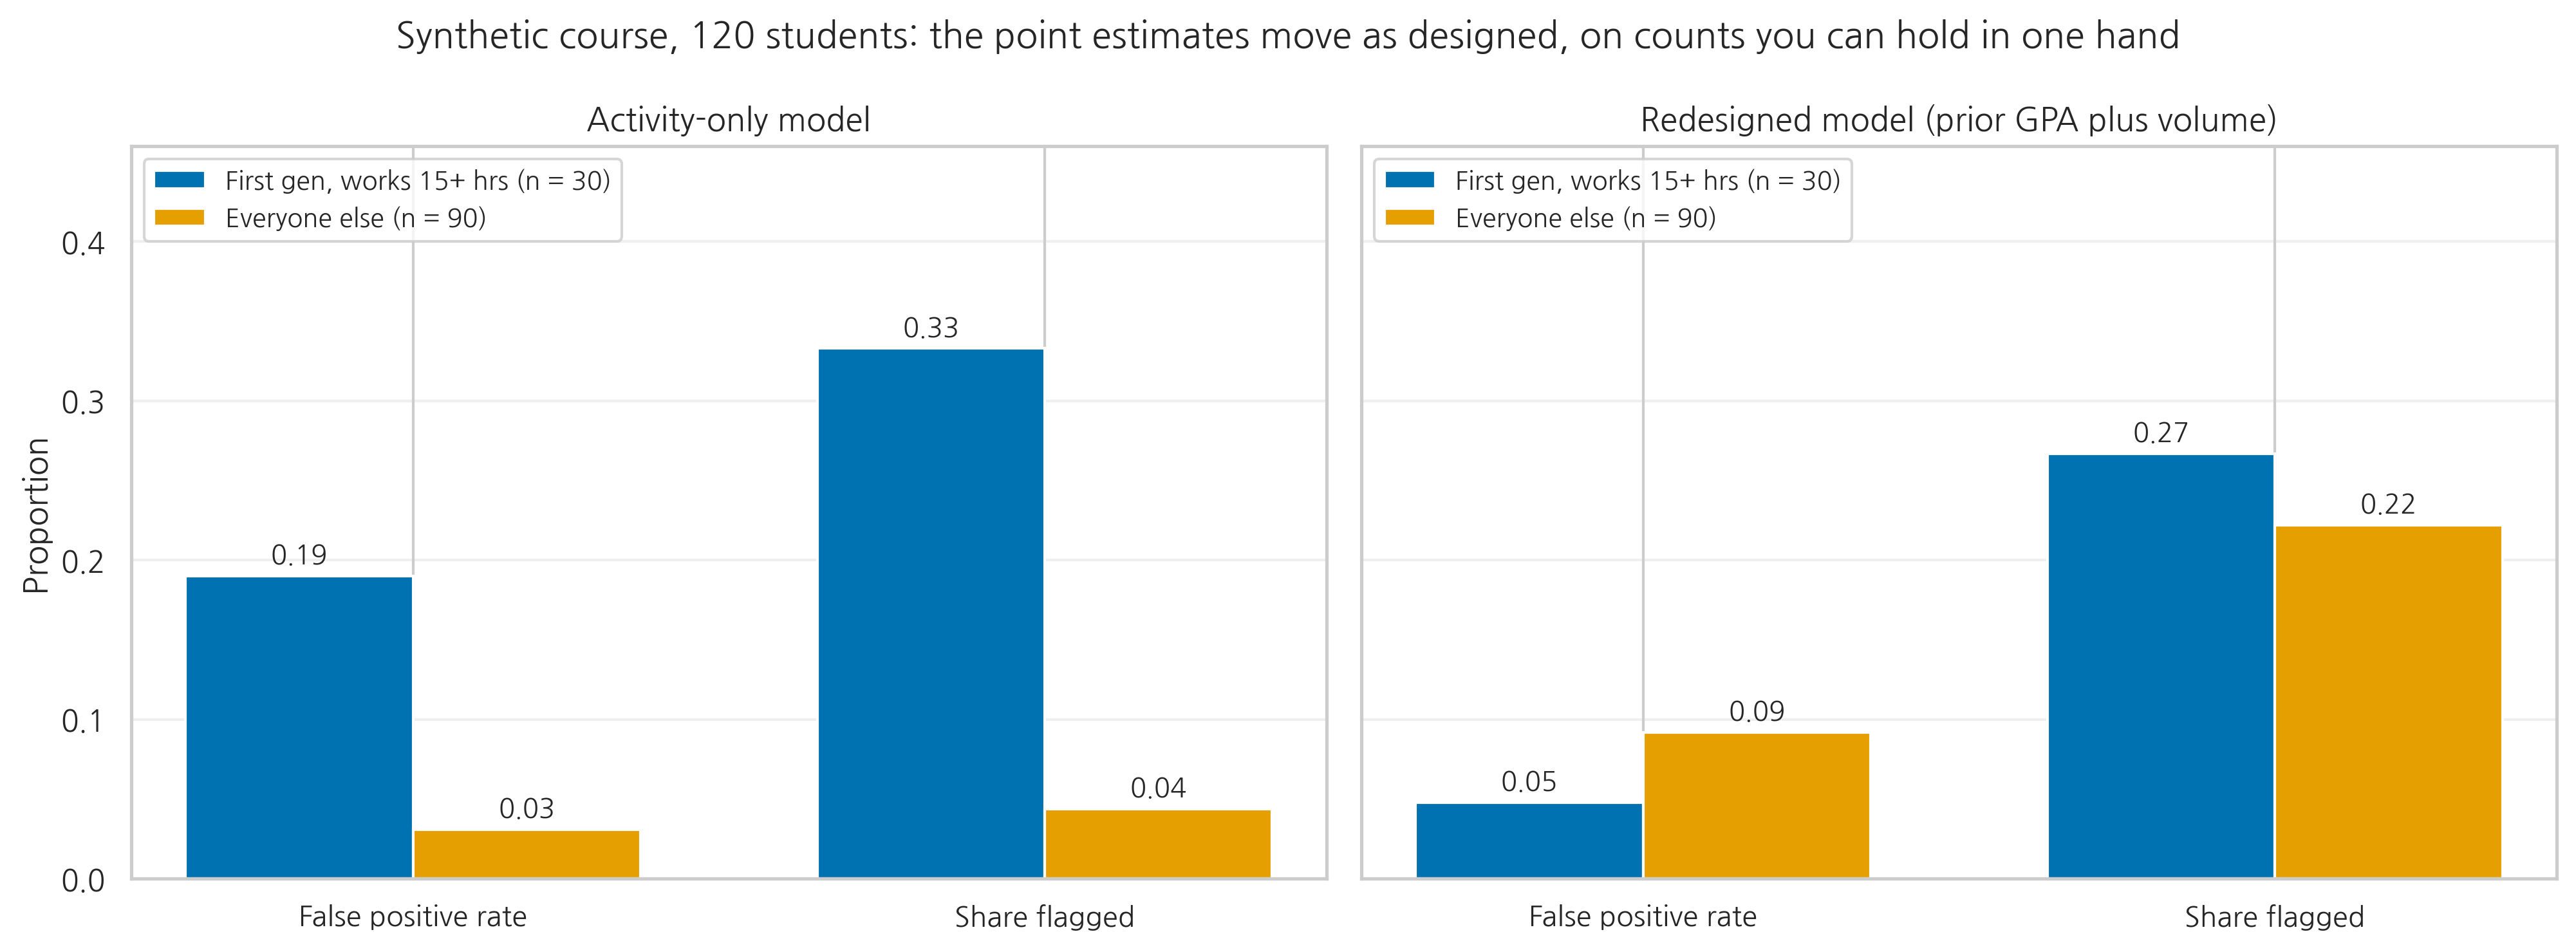

In [14]:
y_synth = synth["below_70"].to_numpy()

def synth_scores(feature_names):
    X = synth[list(feature_names)].to_numpy(dtype=float)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=8100)
    return cross_val_predict(model, X, y_synth, cv=folds, method="predict_proba")[:, 1]

works_long_hours = ((synth["first_gen"] == 1) & (synth["work_hours_per_week"] >= 15)).to_numpy()
SYNTH_GROUPS = {
    "First gen, works 15+ hrs": works_long_hours,
    "Everyone else": ~works_long_hours,
}

def synth_audit(flags):
    """Every rate with the two counts it rests on, because n = 120."""
    rows = []
    for name, mask in SYNTH_GROUPS.items():
        above, below = mask & (y_synth == 0), mask & (y_synth == 1)
        rows.append({
            "group": name, "students": int(mask.sum()),
            "scored 70+ (n)": int(above.sum()),
            "false positives": int(flags[above].sum()),
            "false positive rate": round(float(flags[above].mean()), 3),
            "scored under 70 (n)": int(below.sum()),
            "false negative rate": round(float(1 - flags[below].mean()), 3),
            "flagged": int(flags[mask].sum()),
            "share flagged": round(float(flags[mask].mean()), 3),
        })
    return pd.DataFrame(rows).set_index("group")

def two_by_two_p(flags, restrict=None):
    """Fisher exact p for the difference between the two groups, on counts."""
    from scipy.stats import fisher_exact
    a_mask = works_long_hours if restrict is None else works_long_hours & restrict
    b_mask = ~works_long_hours if restrict is None else (~works_long_hours) & restrict
    a, b = int(flags[a_mask].sum()), int(a_mask.sum())
    c, d = int(flags[b_mask].sum()), int(b_mask.sum())
    return fisher_exact([[a, b - a], [c, d - c]])[1]

synth_activity_flags = (synth_scores(["total_events", "active_days"]) >= THRESHOLD).astype(int)
synth_redesign_flags = (synth_scores(["prior_gpa", "total_events"]) >= THRESHOLD).astype(int)

audit_synth_activity = synth_audit(synth_activity_flags)
audit_synth_redesign = synth_audit(synth_redesign_flags)

print(f"Activity-only features (total_events, active_days): "
      f"accuracy {(synth_activity_flags == y_synth).mean():.3f}, "
      f"flagged {int(synth_activity_flags.sum())}")
print(f"Redesigned features (prior_gpa, total_events)     : "
      f"accuracy {(synth_redesign_flags == y_synth).mean():.3f}, "
      f"flagged {int(synth_redesign_flags.sum())}")
print(f"'Never flag anybody'                              : accuracy {(y_synth == 0).mean():.3f}")
print("\nNotice the first line against the third: on this invented course the activity-only")
print("model barely beats flagging nobody at all. It is a weak model, and weak models")
print("produce fragile subgroup rates. Read every proportion below next to its counts.\n")

print("ACTIVITY-ONLY MODEL on the synthetic course")
print(audit_synth_activity.to_string())
print("\nREDESIGNED MODEL on the synthetic course")
print(audit_synth_redesign.to_string())

print("\nTHE TWO DIFFERENCES, WITH THE COUNTS THEY REST ON")
for label, table, flags in [("activity-only", audit_synth_activity, synth_activity_flags),
                            ("redesigned", audit_synth_redesign, synth_redesign_flags)]:
    fp_gap = (table.loc["First gen, works 15+ hrs", "false positive rate"]
              - table.loc["Everyone else", "false positive rate"])
    sel_gap = (table.loc["First gen, works 15+ hrs", "share flagged"]
               - table.loc["Everyone else", "share flagged"])
    print(f"\n  {label}")
    print(f"    false positive rate gap {fp_gap:+.3f}   "
          f"(false positives: {table.loc['First gen, works 15+ hrs', 'false positives']} of "
          f"{table.loc['First gen, works 15+ hrs', 'scored 70+ (n)']} against "
          f"{table.loc['Everyone else', 'false positives']} of "
          f"{table.loc['Everyone else', 'scored 70+ (n)']})"
          f"   Fisher exact p = {two_by_two_p(flags, y_synth == 0):.3f}")
    print(f"    share flagged gap       {sel_gap:+.3f}   "
          f"({table.loc['First gen, works 15+ hrs', 'flagged']} of 30 against "
          f"{table.loc['Everyone else', 'flagged']} of 90)"
          f"   Fisher exact p = {two_by_two_p(flags):.4f}")

# ---------------------------------------------------------------- figure 4
labels = ["False positive rate", "Share flagged"]
xpos = np.arange(len(labels))
width = 0.36
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharey=True)

for ax, (title, table) in zip(axes, [("Activity-only model", audit_synth_activity),
                                     ("Redesigned model (prior GPA plus volume)", audit_synth_redesign)]):
    a = [table.loc["First gen, works 15+ hrs", "false positive rate"],
         table.loc["First gen, works 15+ hrs", "share flagged"]]
    b = [table.loc["Everyone else", "false positive rate"],
         table.loc["Everyone else", "share flagged"]]
    ax.bar(xpos - width / 2, a, width, color=BLUE, label="First gen, works 15+ hrs (n = 30)")
    ax.bar(xpos + width / 2, b, width, color=ORANGE, label="Everyone else (n = 90)")
    for i, (va, vb) in enumerate(zip(a, b)):
        ax.text(i - width / 2, va + 0.008, f"{va:.2f}", ha="center", fontsize=10)
        ax.text(i + width / 2, vb + 0.008, f"{vb:.2f}", ha="center", fontsize=10)
    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, fontsize=10.5)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left", fontsize=9.5)

axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 0.46)
fig.suptitle("Synthetic course, 120 students: the point estimates move as designed, "
             "on counts you can hold in one hand", fontsize=13.5)
fig.tight_layout()
plt.show()


**Compare this to figure 3, and then read the counts.** On the synthetic course the point estimates behave exactly as a designed disparity should: the activity-only model flags 10 of the 30 students who work long hours and 4 of the other 90, and after the feature swap the two rates are indistinguishable while the accuracy goes up.

Now the honest reading, which is the reason this cell prints counts and p-values.

The **share flagged** difference is solid on its own terms: 10 of 30 against 4 of 90, Fisher exact p around 0.0001. The **false positive rate** difference, the one the fairness literature would headline, rests on four false positives against two. Its p-value is about 0.03, which is to say it is the sort of result that would fail to replicate about as often as it replicated. On 120 students, an audit simply cannot establish a false positive rate disparity, and neither can most real audits of small programmes.

So the honest sentence is not "the audit proved the mechanism and then proved the fix." It is: **the audit found what the generator planted, on evidence far too thin to have found it if we had not already known what to look for.** That is a good thing to have felt once. It is what most subgroup fairness reporting looks like from the inside.

**Two questions to hold:** why should you not trust this audit result the way you trust the OULAD one, given that this dataset has no confounding at all? And why is section 8, which does not run an audit, the section that actually settles the question?

## 📊 8. Prove the mechanism, which is the thing you cannot do upstairs

On the real data we said "the model may be leaning on a feature that stands in for material circumstance," and that was a hypothesis with evidence.

Here it is not a hypothesis. The generator returns the latent traits it used, so we can open the hood and read them. The next cell compares the 30 students who are first generation and work 15 or more hours a week against the other 90 on four things: the invented `ability` trait that drives their scores, their actual quiz average, their total clicks, and their active days. Each comparison gets a test, so that "these are the same" and "these are different" are claims rather than impressions.

Predict which of the four will differ before you run it.

WHAT THE GENERATOR ACTUALLY DID


                                       first gen, 15+ hrs (n = 30)  everyone else (n = 90)  difference              ratio
latent ability (mean, invented trait)                         0.02                    0.06       -0.04   (not meaningful)
mean quiz score (median)                                     75.78                   76.39       -0.61               0.99
total clickstream events (median)                           298.00                  307.50       -9.50               0.97
distinct active days (median)                                 7.00                   30.00      -23.00               0.23

IS EACH DIFFERENCE DISTINGUISHABLE FROM NOISE? (n = 30 against n = 90)
  latent ability          Welch t-test          p = 0.843
  mean quiz score         Mann-Whitney U        p = 8.84e-01
  total click events      Mann-Whitney U        p = 5.79e-01
  distinct active days    Mann-Whitney U        p = 1.52e-15
  Three of the four are nowhere near significant. One is not close to the ot

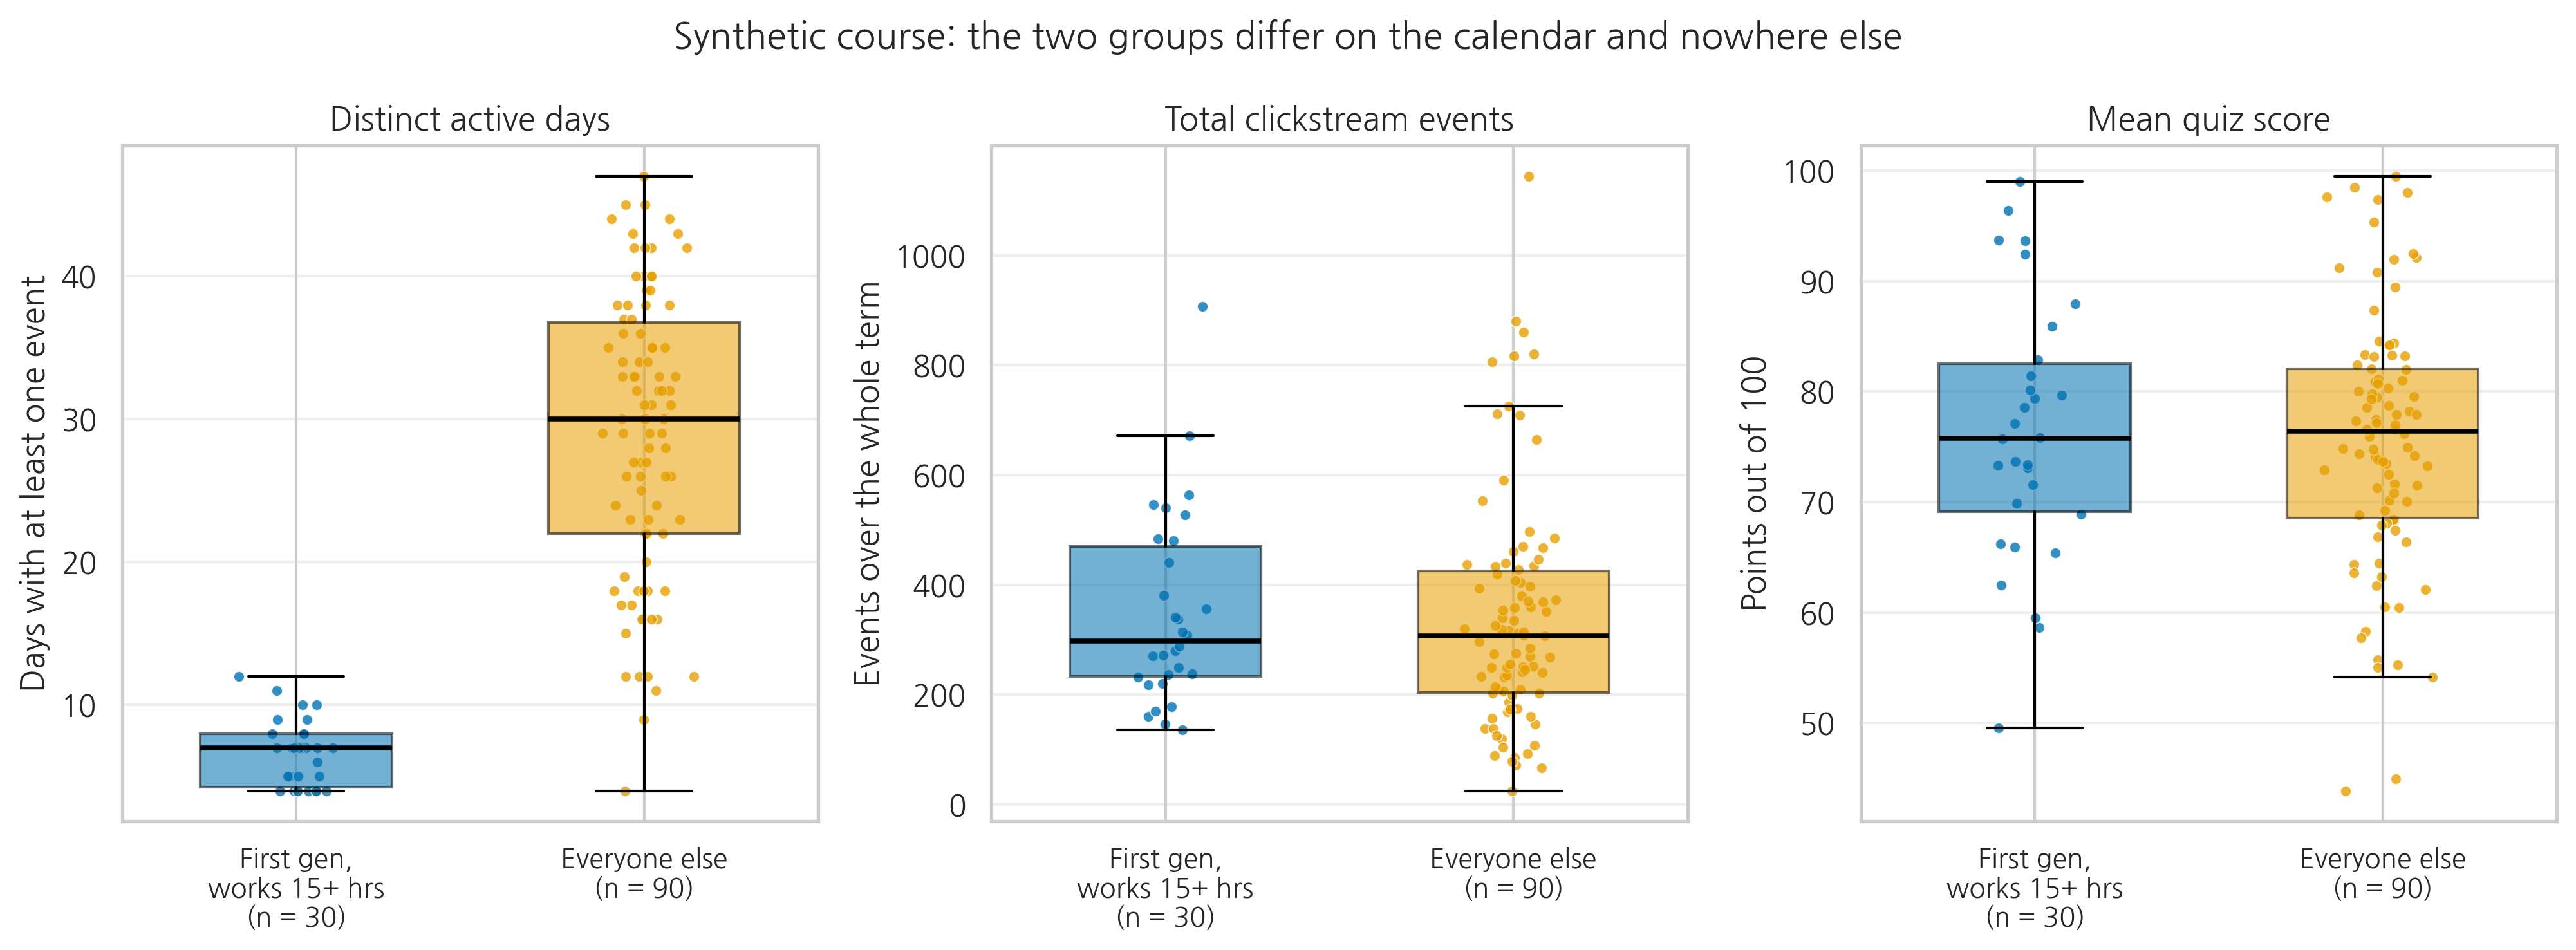

In [15]:
# make_students returns the latent traits. They are never written to students.csv,
# because in weeks 1 and 2 you were supposed to discover the structure, not read it.
latent = make_students(write=False)
latent = latent.merge(synth[["student_id", "total_events", "active_days", "mean_quiz", "below_70"]],
                      on="student_id")
is_burst = latent["concentrated_schedule"] == 1

comparison = pd.DataFrame({
    "first gen, 15+ hrs (n = 30)": [
        latent.loc[is_burst, "ability"].mean(),
        latent.loc[is_burst, "mean_quiz"].median(),
        latent.loc[is_burst, "total_events"].median(),
        latent.loc[is_burst, "active_days"].median(),
    ],
    "everyone else (n = 90)": [
        latent.loc[~is_burst, "ability"].mean(),
        latent.loc[~is_burst, "mean_quiz"].median(),
        latent.loc[~is_burst, "total_events"].median(),
        latent.loc[~is_burst, "active_days"].median(),
    ],
}, index=["latent ability (mean, invented trait)",
          "mean quiz score (median)",
          "total clickstream events (median)",
          "distinct active days (median)"])
comparison["difference"] = comparison.iloc[:, 0] - comparison.iloc[:, 1]
# A ratio only means something for the three measured counts. `ability` is a z-score
# centred on zero, so dividing one near-zero number by another would invent a story.
comparison["ratio"] = (comparison.iloc[:, 0] / comparison.iloc[:, 1]).round(2)
comparison.loc["latent ability (mean, invented trait)", "ratio"] = np.nan

from scipy import stats as _stats

print("WHAT THE GENERATOR ACTUALLY DID")
print(comparison.round(2).to_string(na_rep="  (not meaningful)"))

print("\nIS EACH DIFFERENCE DISTINGUISHABLE FROM NOISE? (n = 30 against n = 90)")
_p_ability = _stats.ttest_ind(latent.loc[is_burst, "ability"],
                              latent.loc[~is_burst, "ability"], equal_var=False).pvalue
print(f"  latent ability          Welch t-test          p = {_p_ability:.3f}")
for _col, _label in [("mean_quiz", "mean quiz score"),
                     ("total_events", "total click events"),
                     ("active_days", "distinct active days")]:
    _p = _stats.mannwhitneyu(latent.loc[is_burst, _col], latent.loc[~is_burst, _col]).pvalue
    print(f"  {_label:<23} Mann-Whitney U        p = {_p:.2e}")
print("  Three of the four are nowhere near significant. One is not close to the others.")

print(f"\nShare scoring below the 70 line: first gen working 15+ hrs "
      f"{latent.loc[is_burst, 'below_70'].mean():.3f}, "
      f"everyone else {latent.loc[~is_burst, 'below_70'].mean():.3f}")

# ---------------------------------------------------------------- figure 5
panels = [("active_days", "Distinct active days", "Days with at least one event"),
          ("total_events", "Total clickstream events", "Events over the whole term"),
          ("mean_quiz", "Mean quiz score", "Points out of 100")]
jitter = np.random.default_rng(8100)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.0))

for ax, (column, title, ylabel) in zip(axes, panels):
    groups = [latent.loc[is_burst, column].to_numpy(), latent.loc[~is_burst, column].to_numpy()]
    box = ax.boxplot(groups, widths=0.55, patch_artist=True, showfliers=False,
                     medianprops=dict(color="black", linewidth=1.8))
    for patch, colour in zip(box["boxes"], [BLUE, ORANGE]):
        patch.set_facecolor(colour)
        patch.set_alpha(0.55)
    for i, values in enumerate(groups, start=1):
        ax.scatter(jitter.normal(i, 0.055, values.size), values, s=16,
                   color=[BLUE, ORANGE][i - 1], alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["First gen,\nworks 15+ hrs\n(n = 30)", "Everyone else\n(n = 90)"], fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Synthetic course: the two groups differ on the calendar and nowhere else",
             fontsize=13.5)
fig.tight_layout()
plt.show()

**This is the whole contrast, in one chart.**

The two groups sit on top of each other on total events (p = 0.58) and on quiz scores (p = 0.88), and their invented ability traits are statistically indistinguishable (p = 0.84). They are far apart on active days, and only on active days: a median of 7 against a median of 30, p around 1e-15.

Here is the human version. Someone working 25 hours a week studies on Sunday afternoon and Wednesday night, in long concentrated blocks. Same reading, same problem sets, same grades, fewer calendar squares with anything in them. `active_days` was quietly standing in for "has a week that looks like a full-time student's week."

And regularity is not a fake signal. For the other 90 students it genuinely predicts achievement, which is exactly why the model picked it up. The model learned a real relationship and then applied it to a group where the relationship does not hold. Nothing about the model was broken. The feature was doing two jobs and only one of them was the job it was hired for.

**We know all of that with certainty**, and it is worth being precise about where the certainty came from. It did not come from the audit in section 7, which rested on four false positives. It came from the latent `ability` column and the two lines of generator code. No observational dataset will ever hand you either, which is the entire reason this notebook has two halves.

**Discuss:** name one thing you now believe about the synthetic course that you could not establish about OULAD no matter how much analysis you did.

## 💬 Why the course keeps both datasets

Put the two halves of this notebook next to each other.

**On the synthetic course**, you found a difference in who got flagged, read the mechanism straight off the generator, removed the feature, and watched the difference stop being detectable while accuracy improved. One step of that was verifiable and the others were not: the *mechanism* was verifiable, because somebody typed it before the data existed. The *audit* rested on counts small enough to write on a napkin. You did not discover the mechanism. You confirmed it, using evidence that would not have been enough to find it.

**On OULAD**, you found a gradient in who got flagged, showed that a chunk of the error-rate problem came from the feature set, removed those features, and watched the gradient hold still. You cannot say how much of what remains is the module's design, the university's support structures, the labour market around those people's homes, or the measurement itself. You can argue, with evidence, and the argument will not close.

Neither dataset is the honest one on its own.

Synthetic data teaches method with the answer key attached, and it will quietly teach you that bias is usually a fixable design defect, because in a simulation it always is. Somebody wrote the mechanism, so somebody can edit it.

Real data teaches you what an audit actually returns: a gap, and a room full of people who disagree about where it came from. It will not teach you method cleanly, because you can never check your work.

**Tsai and Martinez-Maldonado (2022)** argue that the humans around a system are part of the system. That includes the ones who choose the dataset. A team that only ever validates on simulated data will overestimate how much of unfairness is fixable in code. A team that only ever works on institutional data will lose the ability to tell a bad feature from a hard world.

The single sentence to leave with: **a fairness audit measures a model, and a gap measures a world, and the two get reported in the same table as though they were the same kind of fact.**

And one more, about the name we started with: everything above would read differently, and worse, if the column had been called `at_risk`. "The model flagged 62 percent of the enrollments in the most deprived decile" is a sentence about a model. "62 percent of students in the poorest decile are at risk" is a sentence about people, it is not supported by anything in this notebook, and it is the sentence that would have ended up in the memo.

## 💬 Reflection

Bring answers to the discussion block. These are for talking, not for uploading.

**1. Where the bias entered, and who can revise it.** Tsai and Martinez-Maldonado (2022), in "Human-centered approaches to data-informed feedback," argue that the humans around a system are part of the system. In this notebook harm entered at a choice about which columns to use. Who, in a real university, makes that choice? Who currently has the standing to challenge it, and who should?

**2. What the audit cannot see.** Holstein and Doroudi (2022), "Equity and artificial intelligence in education," push past narrow definitions of algorithmic fairness. We checked error rates across two attributes and found no detectable disparity in either, on groups whose recorded outcomes differed a great deal. Name a form of inequity that this notebook's audit is structurally incapable of detecting, no matter how many groups we add to the table. Then answer the harder version: adding more groups makes the table longer and the largest number in it less trustworthy. What is the responsible way to look for a gap you did not predict?

**3. The flag lands on a person.** Lee and Gargroetzi (2023), "'It's like a double-edged sword': Mentor perspectives on ethics and responsibility in a learning analytics-supported virtual mentoring program," found mentors holding real ambivalence about being handed information about the students they were supporting. Imagine you are the advisor who receives the list this model produced. What are you told about how it was made? What would you want to be told? What would you do differently on Monday if the answer were "nothing"?

**4. Optional, connecting to the fourth reading.** Borchers, Liu, Lee, and Zhang (2024), "Ethical AIED and AIED ethics," ask what it would take for ethical frameworks and technical research to actually meet. Where in this 30-minute workflow would a framework have had to intervene to prevent harm, and which of those points already had somebody standing at it?

**5. On the data itself.** Kuzilek, Hlosta, and Zdrahal (2017) released these records so that people outside their institution could study early warning systems. That decision made today's session possible. It also means several thousand people from 2013 and 2014 are in our classroom without knowing it. Under what conditions would you release a dataset like this from your own institution, and what would you require of the people who downloaded it?

**6. For your own project.** Write one sentence naming a feature you are considering using in your course research project, and one sentence saying who it might mean something different for.

## ✅ Before you leave

**There is nothing to submit to Canvas this week.** Week 3 is a launch: we run the audit together in class and carry it into the discussion block. The first Canvas deliverable is Mini Project 1, due in week 4.

- [ ] Ran every cell from the top with no errors (`Runtime > Restart and run all` if in doubt)
- [ ] Can name the dataset, its license, and who collected it, without scrolling up
- [ ] Changed `MY_THRESHOLD` at least once and watched the flag counts and the gaps move
- [ ] Ran the redesign cell, and know which features are in your version of the model
- [ ] Can say in one sentence what the redesign fixed on OULAD and what it did not
- [ ] Can say why "the spread of error rates narrowed" is not a claim this notebook is willing to make
- [ ] Can say in one sentence why the synthetic result looked cleaner, and why the cleanliness came from the generator rather than from the audit
- [ ] Can explain to somebody who was not here why the target column is called `did_not_pass`
- [ ] Have one question ready for our guest, Hansol Lee (Stanford University)
- [ ] Saved a copy if you edited anything you want to keep (`File > Save a copy in Drive`)

**A note on AI use.** If you used an AI assistant anywhere in this notebook, to explain a line of code, to check your reading of a chart, or to draft a reflection, save that exchange now. Starting with Mini Project 1 in week 4, the course AI policy requires you to upload your AI interaction log plus a short reflection alongside the notebook, in the Canvas "AI Reflection" submission. Undisclosed AI use is an Honor Code violation. Building the habit this week, when nothing is being graded, is much cheaper than starting it under a deadline.

## Appendix: solutions to the ✏️ Your turn cells

Read these after you have tried the cells yourself. The point is not the code, it is what the numbers do.

### Your turn 1: the threshold

```python
MY_THRESHOLD = 0.3     # then 0.5, then 0.7
```

Lowering the threshold flags more students, so false positives climb in every decile and false negatives fall in every decile. Raising it does the reverse. What you are watching is a dial that trades one kind of harm for the other, with no setting that removes both.

The thing to notice is what does **not** move. At every threshold anyone would actually use, the most deprived decile is flagged more often than the least deprived, and it is the only one of the three gaps whose bootstrap interval stays clear of zero. The share-flagged gap is +0.148 at a threshold of 0.3, +0.151 at 0.5, and +0.142 at 0.7. The false positive and false negative gaps straddle zero at every setting. A threshold is a volume knob, not a remedy.

The two ends are both bad in their own way. At `0.3` the model contacts 71.6 percent of the cohort, which is not triage, it is a mailing list. At `0.7` it contacts 32.8 percent and misses 43.7 percent of the enrollments that did not end in a pass. Somebody chooses that number, and in practice they choose it from a staffing budget rather than from anything in this notebook.

### Your turn 2: the feature set

```python
my_features = ["clicks", "n_submitted", "mean_score", "no_submission"]   # the default
```

Things worth trying and what to expect:

```python
my_features = ["mean_score", "no_submission"]
# Accuracy 0.737, roughly where the activity-only model was. Graded work alone is not
# enough here: the click count is doing real work inside the default set. Worth
# knowing before you argue that an early warning system needs no clickstream.

my_features = ["clicks", "active_days", "resources", "n_submitted", "mean_score", "no_submission"]
# Accuracy 0.788, the same as the default to three decimals. But the share-flagged
# gradient steepens from about -0.018 to about -0.021 per decile step, and the gap
# between the end deciles goes from 0.180 to 0.202. Putting the schedule-shape
# features back in bought no accuracy and made the flag list skew harder. Adding a
# defensible feature beside a suspect one is not a remedy for the suspect one.
# (Do not compare the error-RATE spreads across these variants. Ten cells of this
# size produce a spread of about 0.09 by chance, so those comparisons are noise.)

my_features = ["num_of_prev_attempts", "studied_credits"]
# Accuracy 0.575, barely above the 0.491 you get by never flagging anybody. Weak,
# and worth pausing on anyway: studied_credits is how much somebody is carrying at
# once, which for many people is a fact about money and time rather than about
# learning. It predicts a little, and it predicts for reasons you may not want to
# act on.
```

The move to notice across all of these: the algorithm never changed. Every difference you produced came from a decision a person made about what the model was allowed to look at. And on OULAD, none of them closed the gradient in who gets flagged. One of them made it steeper.

### Your turn 3: auditing another column

```python
AUDIT_COLUMN = "age_band"     # then "gender", then "highest_education", then "region"
```

Two things usually show up.

First, `age_band` produces a sizeable difference that we never went looking for: the 0 to 35 band is flagged much more often than the 35 to 55 band (0.578 against 0.425 under the activity-only model), and its false positive rate is considerably higher (0.341 against 0.200, on 1,363 and 858 enrollments respectively, so this one is not fragile). Whether that is a fairness problem, a fact about who registers for a distance-learning module at different stages of a life, or both, is a question the table cannot settle. Notice that you would never have seen it if you had only audited the two columns we suspected, and notice also that this is now the third attribute we have looked at, so keep a running count of the comparisons you have made.

Second, some columns split the cohort very unevenly. The `55<=` group in `age_band` holds seven enrollments in total, of which three ended in a pass, so a single flag moves its false positive rate by 33 points. `region` splits the 4,529 enrollments thirteen ways, which produces thirteen small denominators and thirty-nine more chances for the largest number on the screen to be nothing at all.

Reporting a rate like that without its denominator would be the kind of confident, fragile claim this course keeps asking you to refuse. It is the same discipline the bootstrap intervals enforced on the disability column, and the same discipline the noise-range simulation enforced on the deciles.